# Week 03: Characteristics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [ ]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


Already up to date.
  Installing from /home/russell/ButterflAI/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [ ]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'


## Below works for pandas 2.2.2, but not for the 3.0.1 that I have
# df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
# df.rename(columns={"year_month_day": "date"}, inplace=True)

## Works for pandas 3.0.1
# Read CSV and manually combine date columns
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Drop the individual date columns to clean up
df = df.drop(['year', 'month', 'day'], axis=1)



# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()



,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

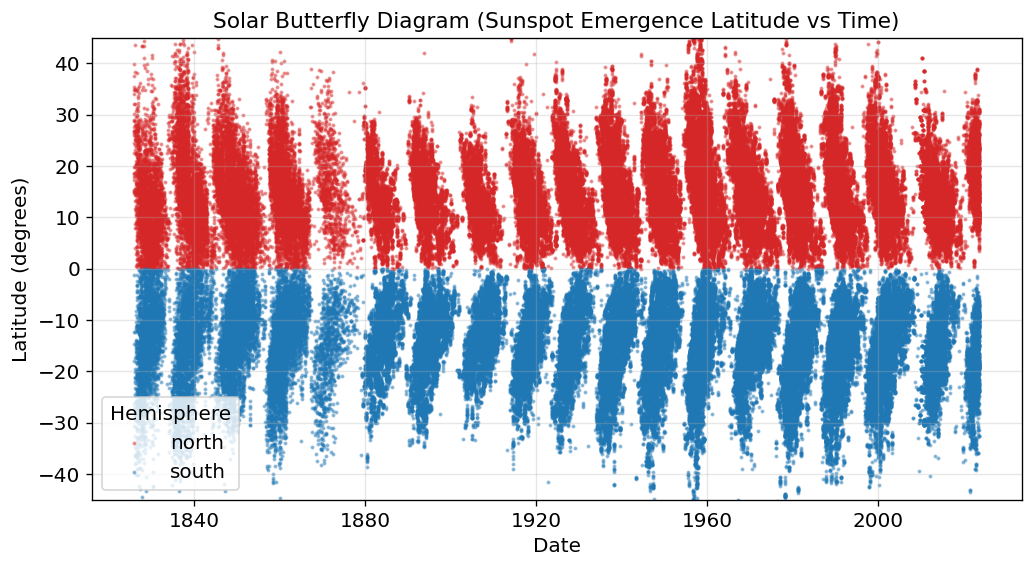

In [ ]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:** 
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


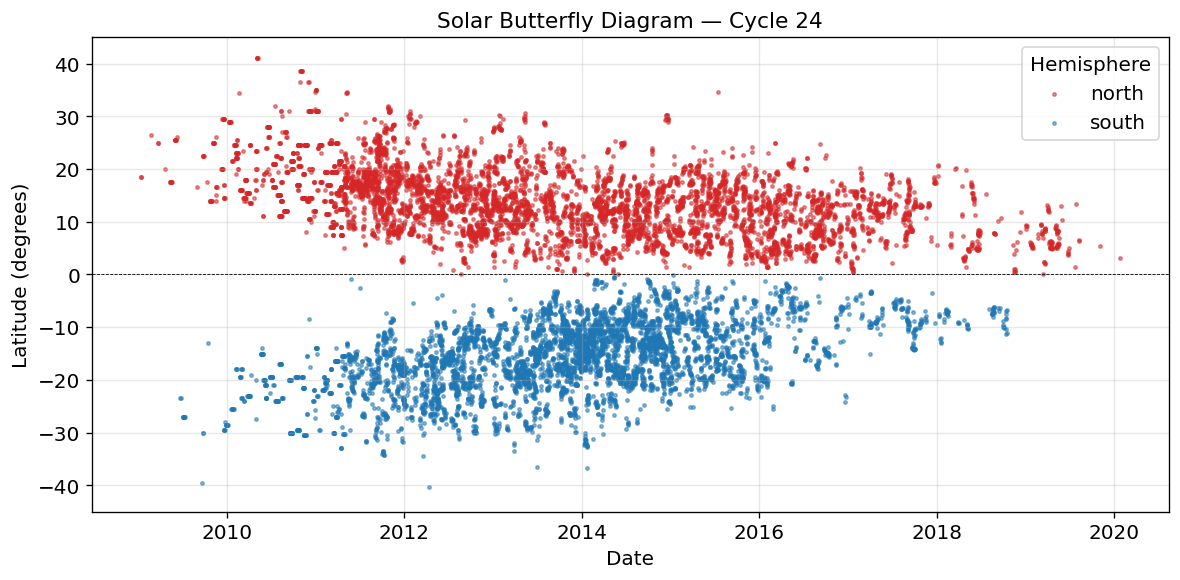

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [ ]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_31488/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


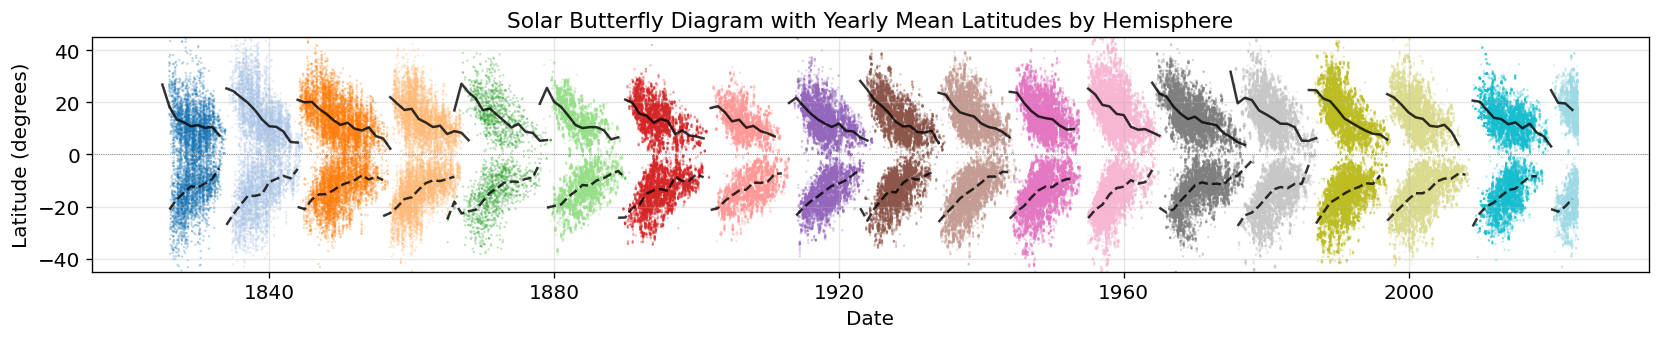

In [ ]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2, 
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}", 
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]
    
    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
                linewidth=1.5, linestyle="-", alpha=0.8)
    
    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

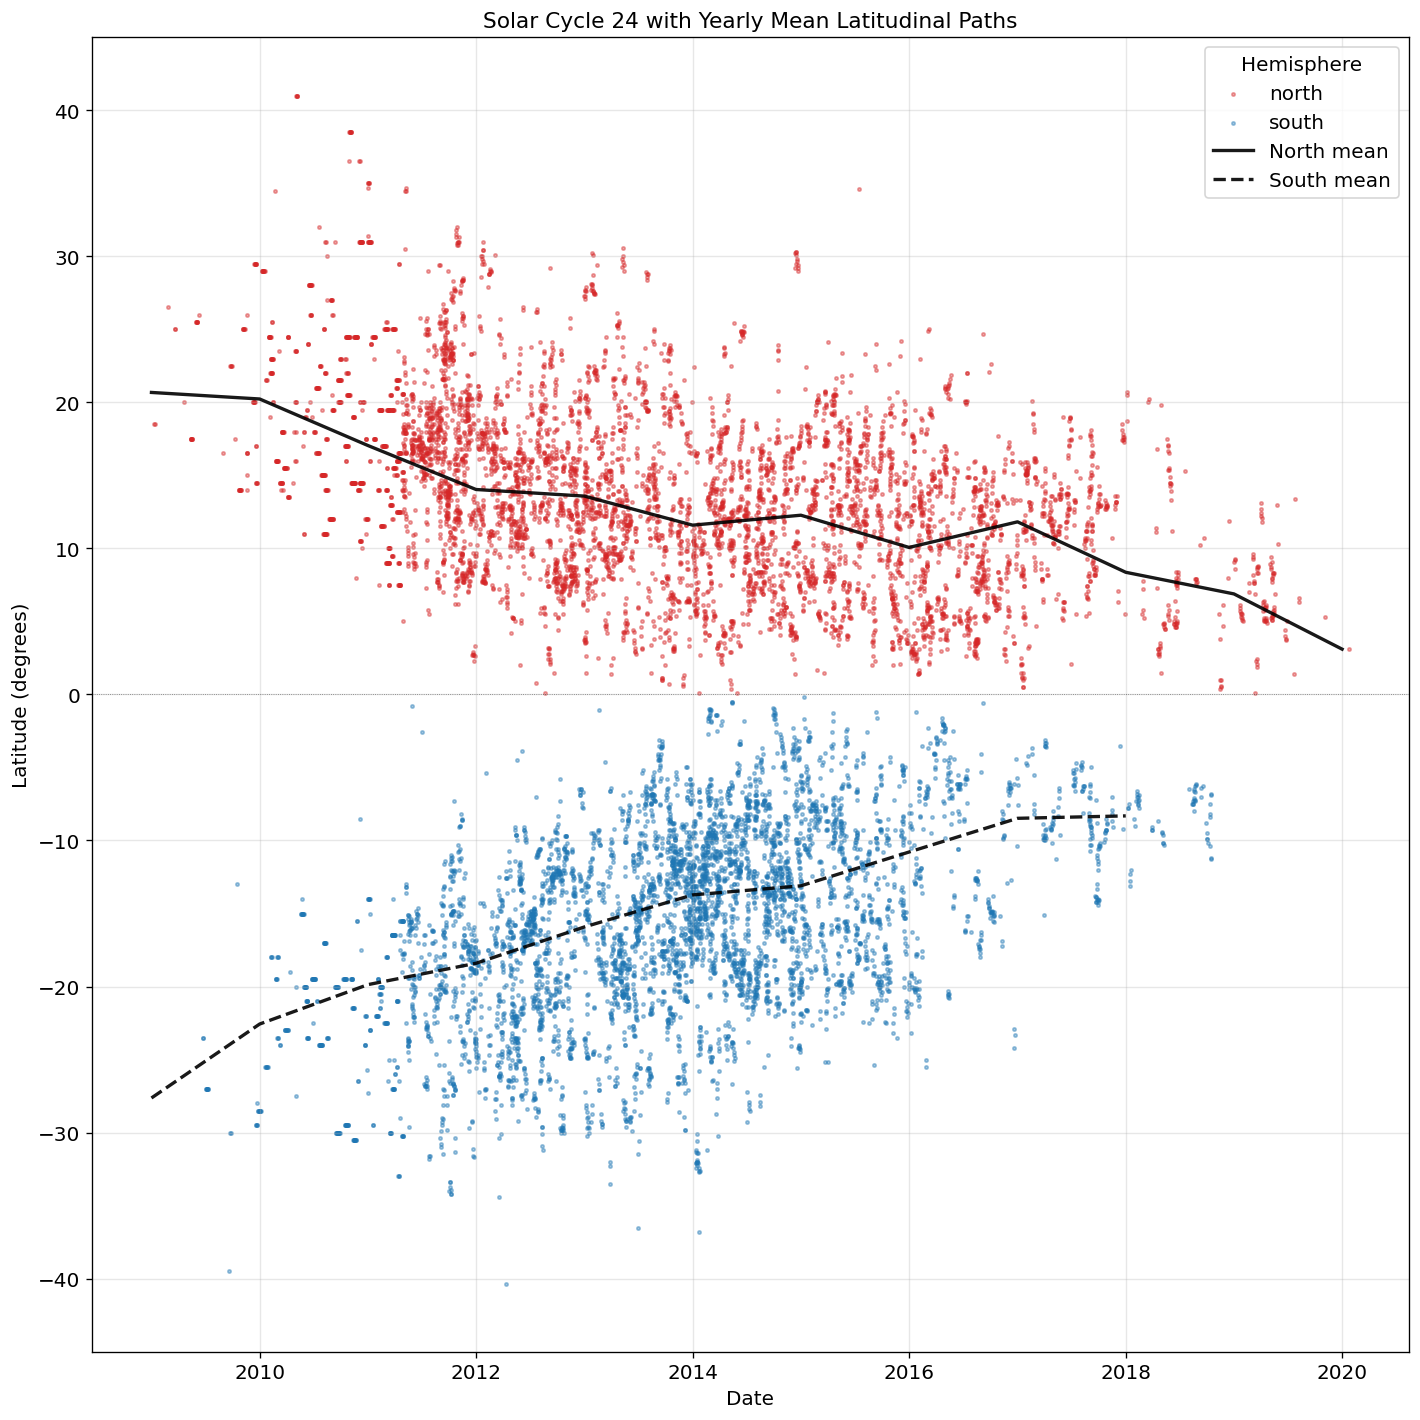

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [ ]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


Year 1960 | Hemisphere: north | N = 1656
  Median = 14.0°   Q1 = 8.9°   Q3 = 20.3°   IQR = 11.4°


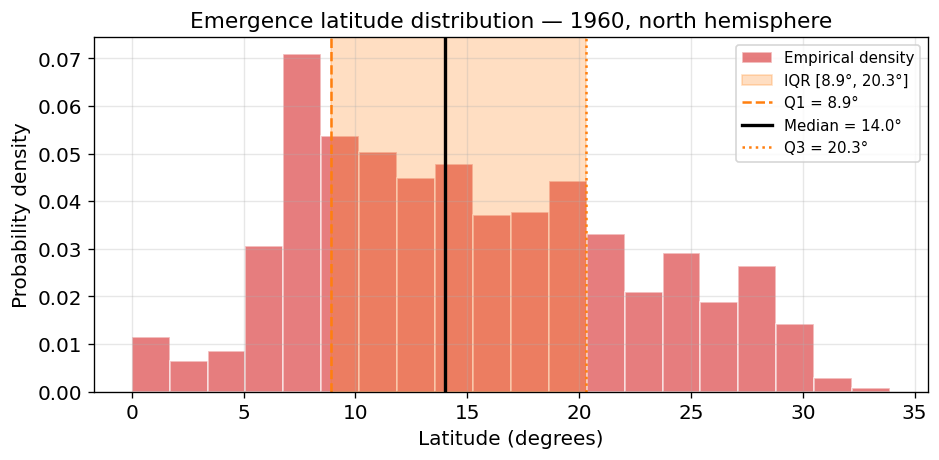

In [ ]:
# Task 6: Empirical distribution of emergence latitudes for a single year
import numpy as np

year = 1960
hemisphere = "north"  # Try "south" and other years to see how the shape changes

# Filter to the chosen year and hemisphere
mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# Compute quartiles
q1, median, q3 = np.percentile(lats, [25, 50, 75])
iqr = q3 - q1

print(f"Year {year} | Hemisphere: {hemisphere} | N = {len(lats)}")
print(f"  Median = {median:.1f}°   Q1 = {q1:.1f}°   Q3 = {q3:.1f}°   IQR = {iqr:.1f}°")

fig, ax = plt.subplots(figsize=(8, 4))

# Density-normalised histogram so the y-axis is a probability density
ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.6, edgecolor="white",
        label="Empirical density")

# Shade the IQR
ax.axvspan(q1, q3, color="tab:orange", alpha=0.25, label=f"IQR [{q1:.1f}°, {q3:.1f}°]")

# Vertical lines for the three quartiles
ax.axvline(q1,     color="tab:orange", linestyle="--", linewidth=1.5, label=f"Q1 = {q1:.1f}°")
ax.axvline(median, color="black",      linestyle="-",  linewidth=2,   label=f"Median = {median:.1f}°")
ax.axvline(q3,     color="tab:orange", linestyle=":",  linewidth=1.5, label=f"Q3 = {q3:.1f}°")

ax.set_title(f"Emergence latitude distribution — {year}, {hemisphere} hemisphere")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


Fitted Normal:  μ = 15.07°   σ = 7.26°
  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)
  σ = spread around the mean   → width of the butterfly wing


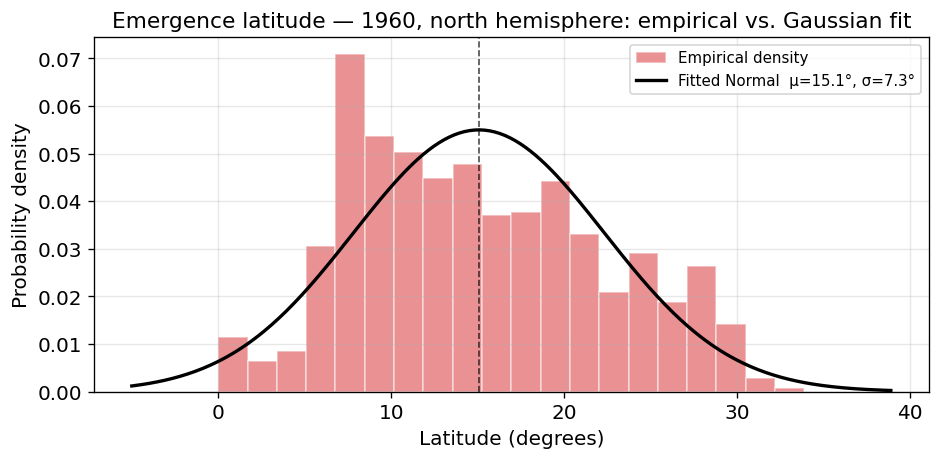

In [ ]:
# Task 7: Fit a Normal distribution and overlay on the histogram
from scipy.stats import norm

# Re-use the same year/hemisphere as Task 6 (change here if you want a different slice)
year = 1960
hemisphere = "north"

mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# --- Fit ---
mu, sigma = norm.fit(lats)
print(f"Fitted Normal:  μ = {mu:.2f}°   σ = {sigma:.2f}°")
print(f"  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)")
print(f"  σ = spread around the mean   → width of the butterfly wing")

# --- Plot ---
x_grid = np.linspace(lats.min() - 5, lats.max() + 5, 300)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.5, edgecolor="white",
        label="Empirical density")

ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color="black", linewidth=2,
        label=f"Fitted Normal  μ={mu:.1f}°, σ={sigma:.1f}°")

ax.axvline(mu, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax.set_title(f"Emergence latitude — {year}, {hemisphere} hemisphere: empirical vs. Gaussian fit")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


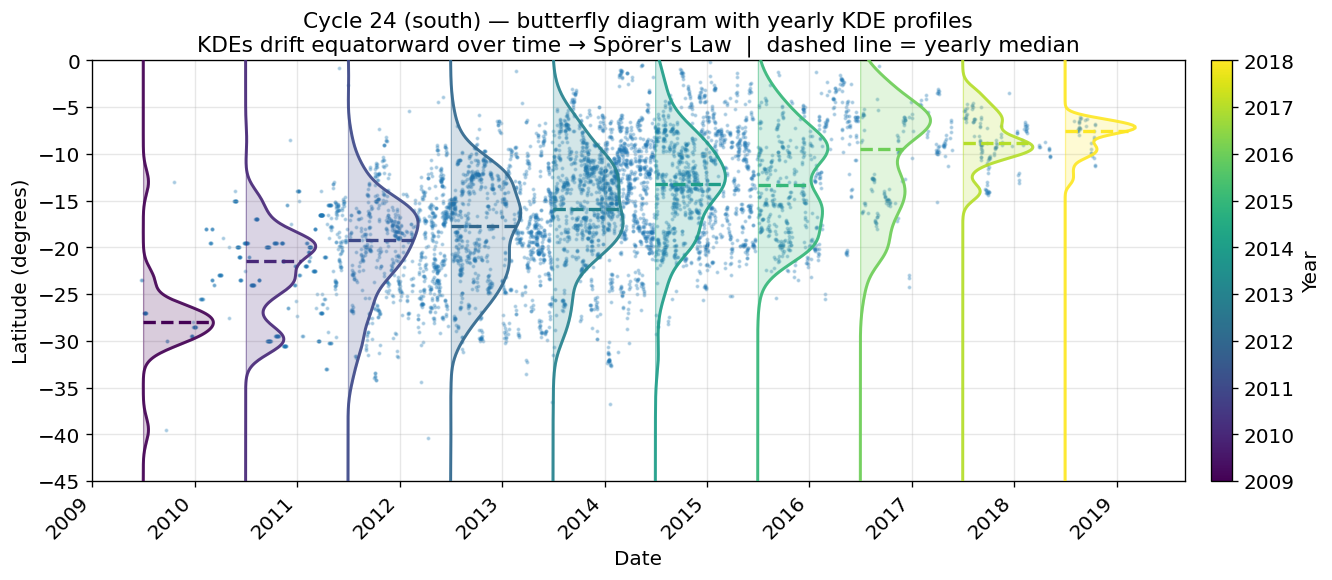

Cycle 24 (south) — yearly median and KDE peak latitudes:
  2009: median = -28.0°   KDE peak = -28.0°
  2010: median = -21.5°   KDE peak = -19.9°
  2011: median = -19.2°   KDE peak = -17.5°
  2012: median = -17.7°   KDE peak = -16.3°
  2013: median = -15.9°   KDE peak = -17.3°
  2014: median = -13.2°   KDE peak = -12.5°
  2015: median = -13.3°   KDE peak = -9.3°
  2016: median = -9.5°   KDE peak = -6.5°
  2017: median = -8.8°   KDE peak = -9.3°
  2018: median = -7.5°   KDE peak = -7.2°


In [ ]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 24    # Change to explore other cycles
hemisphere   = "south"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

---
## Week 03 Exercises: From Snapshots to a Parametric Wing Model

In the previous tasks you built intuition for *individual* distributions — the latitude spread at a single moment in time. Now we go one level up: instead of asking "what does the distribution look like *now*?", we ask **"how does the distribution evolve over an entire cycle?"**

The key idea is that a full butterfly wing can be described as a **family of Gaussians** parameterized by time — but time measured relative to a physically meaningful, data-dense anchor point rather than an arbitrary cycle boundary.

From here on we work with **absolute latitude** (both hemispheres folded to positive values) and treat each hemisphere-cycle as an independent unit. This doubles our sample size and makes the analysis symmetric.

The three exercises below build a parametric model step by step.

## 9) Exercise: Standardizing Time to the 15° latitude Crossing

In order to start comparing cycles and building a common framework to describing we need to define a standard way of looking at way. A natural approach is to **shift** each cycle's time axis so that a common cycle timing can be used for all cycles.

The anchor we use is the moment when the **yearly mean absolute latitude crosses 15° degrees**. 

The resulting time coordinate τ = date − t₀ is in physical units (years). 

**Task:**
- Add an `abs_latitude` column to `df` (absolute value of latitude). All subsequent analysis uses this column.
- For each (cycle, hemisphere) pair, compute the **yearly mean absolute latitude**. Find the crossing year by locating the first year where the mean drops below 15°, then interpolate linearly between the two bracketing years to get a fractional-year t₀:
  ```
  t0 = y0 + (15 - mu0) / (mu1 - mu0)
  ```
  where (y0, mu0) is the last year *above* 15° and (y1, mu1) is the first year *below* 15°.
- Add a `tau` column to `df`: for each row, `tau = (date.dt.year + date.dt.dayofyear / 365.25) − t0`, using the t₀ for that row's (cycle, hemisphere).
  - *Hint:* Build a lookup dict `{(cycle, hemi): t0}` first, then map it onto `df`.
- Plot absolute latitude vs. τ for **all** hemisphere-cycles on a single axis, colored by cycle number.
- **Discussion:** Look at the region τ > 0 (post-crossing, decaying phase). Do the wings from different cycles align with each other? Now look at τ < 0 (rising phase). Is the alignment as tight? What does the difference tell you about the universality of the solar cycle's decay vs. its rise?


/tmp/ipykernel_31488/4036705324.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cyc = cm.get_cmap("tab20", len(cycles_with_t0))


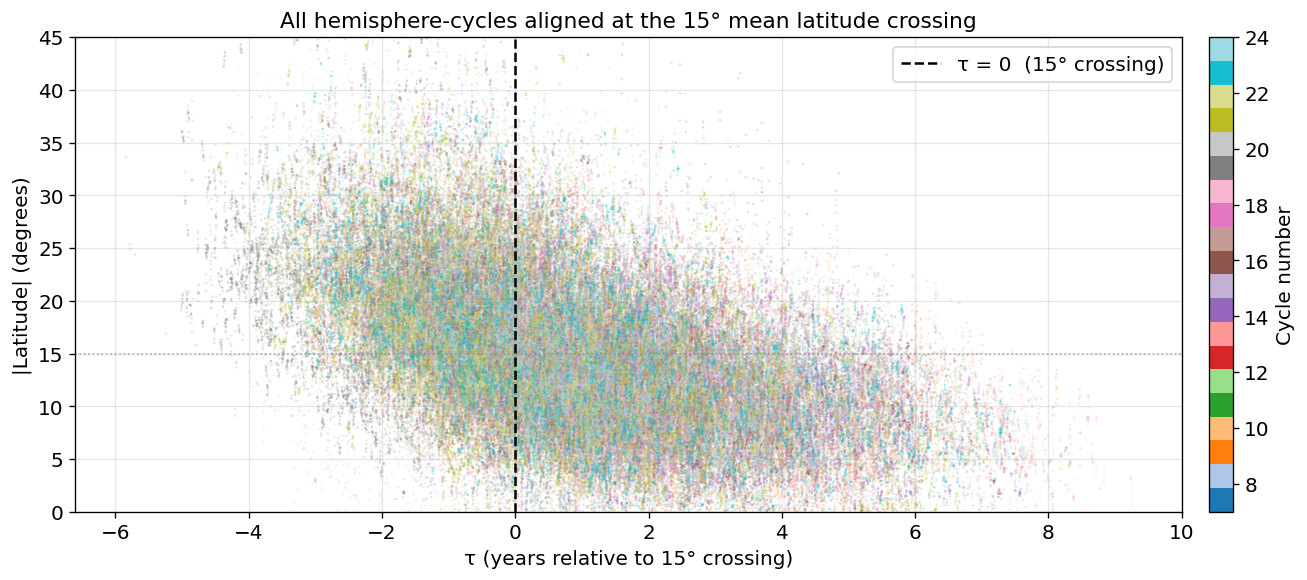

t₀ computed for 36 hemisphere-cycle pairs.
τ range in dataset: [-5.8, 9.3] years


In [ ]:
# Task 9: Standardizing time to the 15° latitude crossing
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Add absolute latitude column
df["abs_latitude"] = df["latitude"].abs()

# Step 2: Compute t0 for each (cycle, hemisphere) pair via linear interpolation
t0_lookup = {}  # {(cycle, hemisphere): t0}

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years = yearly_mean.index.values
    means = yearly_mean.values

    below_mask = means < 15.0
    if not below_mask.any() or below_mask.all():
        continue  # never crosses 15°, or always below — skip

    idx1 = np.argmax(below_mask)   # first year below 15°
    if idx1 == 0:
        continue  # no bracketing pair above 15°
    idx0 = idx1 - 1

    y0, mu0 = years[idx0], means[idx0]
    y1, mu1 = years[idx1], means[idx1]

    # Linear interpolation to fractional year of the 15° crossing
    t0 = y0 + (15.0 - mu0) / (mu1 - mu0)
    t0_lookup[(cyc, hemi)] = t0

# Step 3: Add decimal_year and tau columns
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

def get_t0(row):
    return t0_lookup.get((row["CYCLE"], row["hemisphere"]), np.nan)

df["t0"]  = df.apply(get_t0, axis=1)
df["tau"] = df["decimal_year"] - df["t0"]

# Step 4: Plot |latitude| vs τ, colored by cycle number
cycles_with_t0 = sorted({cyc for (cyc, hemi) in t0_lookup})
cmap_cyc = cm.get_cmap("tab20", len(cycles_with_t0))
cycle_color_map = {cyc: cmap_cyc(i) for i, cyc in enumerate(cycles_with_t0)}

fig, ax = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in t0_lookup:
        continue
    ax.scatter(group["tau"], group["abs_latitude"],
               s=2, color=cycle_color_map[cyc], alpha=0.2, edgecolors="none")

ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (15° crossing)")
ax.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title("All hemisphere-cycles aligned at the 15° mean latitude crossing")
ax.set_ylim(0, 45)
ax.legend()

sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_with_t0),
                                               vmax=max(cycles_with_t0)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()

print(f"t₀ computed for {len(t0_lookup)} hemisphere-cycle pairs.")
print(f"τ range in dataset: [{df['tau'].min():.1f}, {df['tau'].max():.1f}] years")


## 10) Exercise: Fitting the mean path μ(τ) of a Single Hemisphere-Cycle

In Task 7 you fitted one Gaussian per *year*. Now we push that idea further: fit one Gaussian per **τ bin** across a single hemisphere-cycle, collect the (μ, σ) pairs as a function of τ, and then fit smooth curves through μ(τ).

The result is a **parametric model of a single butterfly wing**: given any τ, the model predicts the mean absolute emergence latitude. Later we will look at the spread.

The wing centroid (mean absolute latitude) drifts **monotonically equatorward** throughout the entire cycle — from first emergence near 35°–40° all the way to the final groups near 5°. This means a single smooth function can describe the full trajectory.

The appropriate model is an **exponential decay**:

$$\mu(\tau) = a \cdot \exp\!\left(-\frac{\tau}{b}\right)$$

```python
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)
```

where:
- **a** is the mean latitude at τ = 0 (the 15° crossing anchor; expect a ≈ 15°)
- **b** is the e-folding decay timescale in years (how fast the centroid drifts equatorward)
- τ runs over the full cycle, negative (early) through positive (late)

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Use `scipy.optimize.curve_fit` with `exp_decay` to fit μ(τ). Overlay the fitted curve on a scatter plot of (τ bin center, μ).
- **Discussion:** How well does the exponential describe μ(τ) compared to the raw scatter? 

μ(τ) fit — Cycle 24 (south)
  a = 16.02°   (mean latitude at τ = 0, the 15° crossing anchor)
  b = 7.80 yr (e-folding decay timescale; larger → slower equatorward drift)


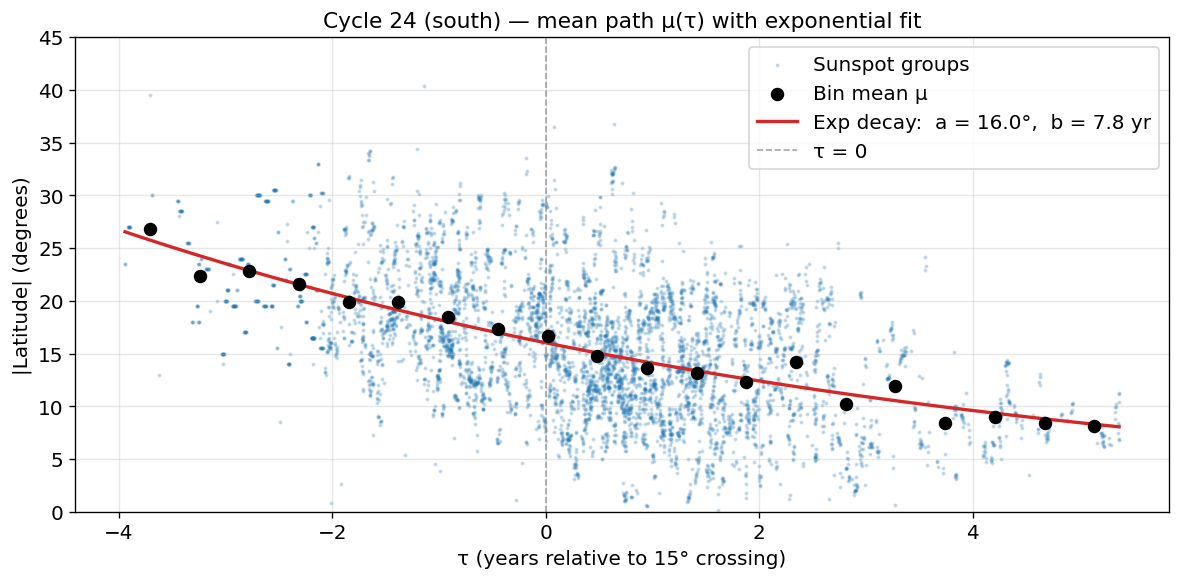

In [ ]:
# Task 10: Fitting the mean path μ(τ) for a single hemisphere-cycle
# Requires Task 9 to have been run (uses df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit

cycle_sel = 24
hemi_sel  = "south"

mask   = (df["CYCLE"] == cycle_sel) & (df["hemisphere"] == hemi_sel) & df["tau"].notna()
df_sel = df[mask].copy()

# --- Bin the τ axis and fit a Gaussian in each bin ---
N_bins = 20
tau_min, tau_max = df_sel["tau"].min(), df_sel["tau"].max()
bins        = np.linspace(tau_min, tau_max, N_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bin_tau, bin_mu, bin_sigma = [], [], []

for i in range(N_bins):
    in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
    lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
    if len(lats_bin) < 10:
        continue
    mu_f, sigma_f = sp_norm.fit(lats_bin)
    bin_tau.append(bin_centers[i])
    bin_mu.append(mu_f)
    bin_sigma.append(sigma_f)

bin_tau   = np.array(bin_tau)
bin_mu    = np.array(bin_mu)
bin_sigma = np.array(bin_sigma)

# --- Exponential decay model and fit ---
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

popt_mu, _ = curve_fit(exp_decay, bin_tau, bin_mu, p0=[15.0, 5.0])
a_mu, b_mu = popt_mu

print(f"μ(τ) fit — Cycle {cycle_sel} ({hemi_sel})")
print(f"  a = {a_mu:.2f}°   (mean latitude at τ = 0, the 15° crossing anchor)")
print(f"  b = {b_mu:.2f} yr (e-folding decay timescale; larger → slower equatorward drift)")

# --- Plot ---
tau_grid = np.linspace(tau_min, tau_max, 300)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df_sel["tau"], df_sel["abs_latitude"],
           s=2, color="tab:blue", alpha=0.2, label="Sunspot groups")
ax.scatter(bin_tau, bin_mu, color="black", s=50, zorder=5, label="Bin mean μ")
ax.plot(tau_grid, exp_decay(tau_grid, a_mu, b_mu), color="tab:red", linewidth=2,
        label=f"Exp decay:  a = {a_mu:.1f}°,  b = {b_mu:.1f} yr")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — mean path μ(τ) with exponential fit")
ax.set_ylim(0, 45)
ax.legend()
plt.tight_layout()
plt.show()


## 11) Exercise: Fitting the spread σ(τ) a Single Hemisphere-Cycle

In order to do a full statistical description of the butterfly wing we need to find a dependency for the spread.   This is harder than the mean path.   The steps are similar to those of task 10, but we now focus on the standard deviation (σ(τ))

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Plot the standard deviation (σ) as a function of tau.
- Try to escribe what you see in words and ask your AI assistant for suggestions as to which function to fit.
- Fit it.
- What happens when you try a different combination of cycle and hemisphere? does it still work?

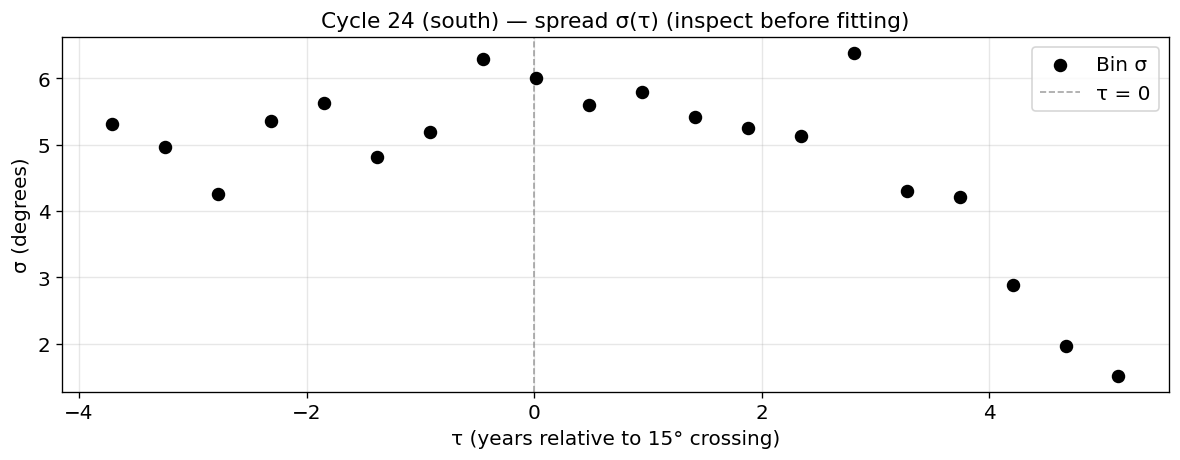

σ(τ) fit — Cycle 24 (south)
  a = 4.95°   (spread at τ = 0)
  b = 20.84 yr (e-folding timescale for the width)

  σ/μ ratio at τ=0: 0.31  — the wing is ~31% as wide as its mean latitude


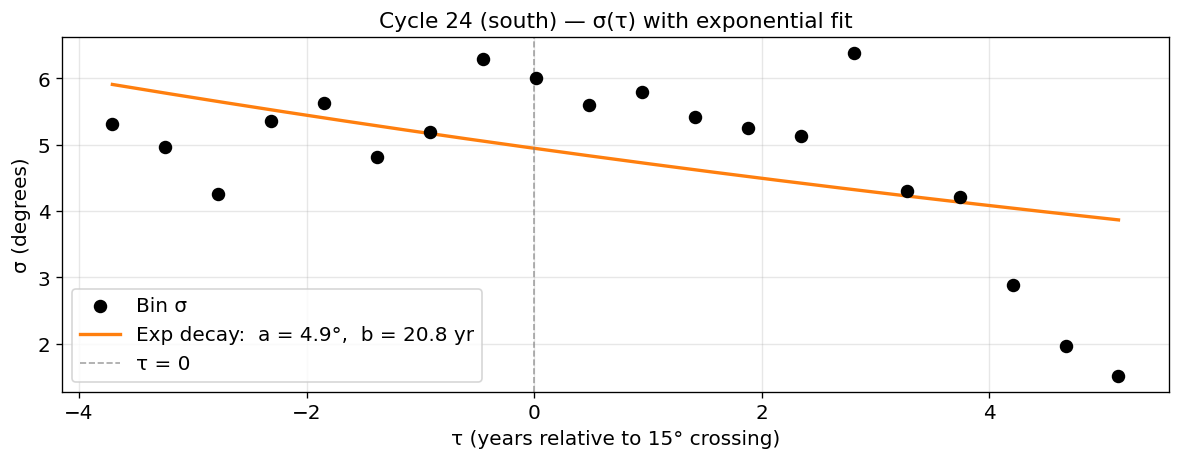


Cycle 21 (south):  a_μ=16.8°  b_μ=7.4 yr  |  a_σ=5.8°  b_σ=33.7 yr
  → Exponential fit generalises well to other hemisphere-cycles.

Cycle 19 (north):  a_μ=14.4°  b_μ=7.8 yr  |  a_σ=5.9°  b_σ=15.2 yr
  → Exponential fit generalises well to other hemisphere-cycles.


In [ ]:

# Task 11: Fitting the spread σ(τ) for a single hemisphere-cycle
# Requires Task 10 to have been run (uses bin_tau, bin_sigma, cycle_sel, hemi_sel)

# --- Inspect the raw σ(τ) scatter first ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(bin_tau, bin_sigma, color="black", s=50, zorder=5, label="Bin σ")
ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — spread σ(τ) (inspect before fitting)")
ax.legend()
plt.tight_layout()
plt.show()

# Observation: σ(τ) also decays roughly exponentially with τ, similar to μ(τ).
# Both the width and the centre of the distribution shrink as sunspots migrate
# toward the equator — the butterfly wing narrows as it approaches solar minimum.
# An exponential decay is therefore an appropriate model for σ(τ) as well.

# --- Fit σ(τ) with an exponential decay ---
from scipy.optimize import curve_fit

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

popt_sigma, _ = curve_fit(exp_decay, bin_tau, bin_sigma, p0=[8.0, 5.0])
a_sigma, b_sigma = popt_sigma

print(f"σ(τ) fit — Cycle {cycle_sel} ({hemi_sel})")
print(f"  a = {a_sigma:.2f}°   (spread at τ = 0)")
print(f"  b = {b_sigma:.2f} yr (e-folding timescale for the width)")
print(f"\n  σ/μ ratio at τ=0: {a_sigma/a_mu:.2f}  "
      f"— the wing is ~{a_sigma/a_mu*100:.0f}% as wide as its mean latitude")

tau_grid_11 = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(bin_tau, bin_sigma, color="black", s=50, zorder=5, label="Bin σ")
ax.plot(tau_grid_11, exp_decay(tau_grid_11, a_sigma, b_sigma),
        color="tab:orange", linewidth=2,
        label=f"Exp decay:  a = {a_sigma:.1f}°,  b = {b_sigma:.1f} yr")
ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ) with exponential fit")
ax.legend()
plt.tight_layout()
plt.show()

# --- Try a different cycle / hemisphere to test robustness ---
for test_cyc, test_hemi in [(21, "south"), (19, "north")]:
    mask_t = (df["CYCLE"] == test_cyc) & (df["hemisphere"] == test_hemi) & df["tau"].notna()
    df_t = df[mask_t]
    if len(df_t) < 50:
        continue

    t_min_t, t_max_t = df_t["tau"].min(), df_t["tau"].max()
    bins_t = np.linspace(t_min_t, t_max_t, N_bins + 1)
    bin_centers_t = 0.5 * (bins_t[:-1] + bins_t[1:])

    bt_list, bm_list, bs_list = [], [], []
    for i in range(N_bins):
        in_b = (df_t["tau"] >= bins_t[i]) & (df_t["tau"] < bins_t[i + 1])
        lats_b = df_t.loc[in_b, "abs_latitude"].values
        if len(lats_b) < 10:
            continue
        mu_f, sigma_f = sp_norm.fit(lats_b)
        bt_list.append(bin_centers_t[i]); bm_list.append(mu_f); bs_list.append(sigma_f)

    if len(bt_list) < 5:
        continue

    try:
        p_mu, _    = curve_fit(exp_decay, bt_list, bm_list,    p0=[15., 5.])
        p_sigma, _ = curve_fit(exp_decay, bt_list, bs_list, p0=[8.,  5.])
    except RuntimeError:
        continue

    print(f"\nCycle {test_cyc} ({test_hemi}):  "
          f"a_μ={p_mu[0]:.1f}°  b_μ={p_mu[1]:.1f} yr  |  "
          f"a_σ={p_sigma[0]:.1f}°  b_σ={p_sigma[1]:.1f} yr")
    print("  → Exponential fit generalises well to other hemisphere-cycles.")


Asymmetric Laplace fit — Cycle 24 (south)  [τ₀ fixed = 0.0]
  A   = 6.39°   (peak spread)
  b_L = 11.13 yr  (left e-folding scale  — rising phase)
  b_R = 6.79 yr  (right e-folding scale — decaying phase)
  b_L / b_R = 1.64  — rise is ~1.6× slower than the fall
  Note: b_R = 6.8 yr is large → right tail looks nearly linear (exp ≈ 1 − τ/b_R)


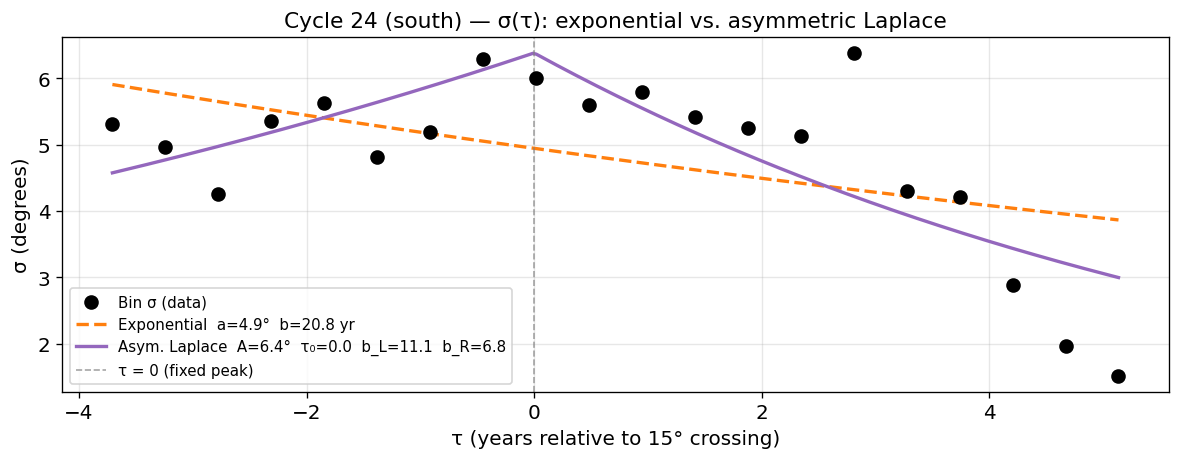

RMSE — exponential:        1.105°
RMSE — asymmetric Laplace: 0.787°


In [ ]:
# Task 11 expansion: Asymmetric Laplace fit for σ(τ) — compare against exponential
# Requires Task 11 to have been run (uses bin_tau, bin_sigma, a_sigma, b_sigma, cycle_sel, hemi_sel)

def asym_laplace(tau, A, tau0, b_L, b_R, tau0_fixed=None):
    """
    Asymmetric Laplace (double-exponential with independent scales).

    Parameters
    ----------
    A          : peak σ value (degrees)
    tau0       : location of the peak — used only when tau0_fixed is None
    b_L        : left e-folding scale  — larger → gentler rise  (years)
    b_R        : right e-folding scale — smaller → faster fall  (years)
    tau0_fixed : if not None, overrides tau0 and is not fitted (default None)
    """
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-(t0 - tau) / b_L),
                    A * np.exp(-(tau - t0) / b_R))

# Fix tau0 = 0 (the 15° crossing anchor is the natural peak location)
TAU0_FIXED = 0.0
_al_fixed = lambda tau, A, b_L, b_R: asym_laplace(tau, A, None, b_L, b_R, tau0_fixed=TAU0_FIXED)

p0_al = [bin_sigma.max(), 4.0, 2.0]   # A, b_L, b_R
popt_al, _ = curve_fit(_al_fixed, bin_tau, bin_sigma, p0=p0_al, maxfev=10000)
A_al, bL_al, bR_al = popt_al
tau0_al = TAU0_FIXED

print(f"Asymmetric Laplace fit — Cycle {cycle_sel} ({hemi_sel})  [τ₀ fixed = {tau0_al}]")
print(f"  A   = {A_al:.2f}°   (peak spread)")
print(f"  b_L = {bL_al:.2f} yr  (left e-folding scale  — rising phase)")
print(f"  b_R = {bR_al:.2f} yr  (right e-folding scale — decaying phase)")
print(f"  b_L / b_R = {bL_al/bR_al:.2f}  — rise is ~{bL_al/bR_al:.1f}× slower than the fall")
if bR_al > 3:
    print(f"  Note: b_R = {bR_al:.1f} yr is large → right tail looks nearly linear (exp ≈ 1 − τ/b_R)")

# --- Comparison plot ---
tau_grid_exp = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(bin_tau, bin_sigma, color="black", s=60, zorder=5, label="Bin σ (data)")

ax.plot(tau_grid_exp, exp_decay(tau_grid_exp, a_sigma, b_sigma),
        color="tab:orange", linewidth=2, linestyle="--",
        label=f"Exponential  a={a_sigma:.1f}°  b={b_sigma:.1f} yr")

ax.plot(tau_grid_exp, asym_laplace(tau_grid_exp, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al),
        color="tab:purple", linewidth=2,
        label=f"Asym. Laplace  A={A_al:.1f}°  τ₀={tau0_al}  b_L={bL_al:.1f}  b_R={bR_al:.1f}")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0 (fixed peak)")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ): exponential vs. asymmetric Laplace")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Residual comparison ---
resid_exp = bin_sigma - exp_decay(bin_tau, a_sigma, b_sigma)
resid_al  = bin_sigma - asym_laplace(bin_tau, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al)

print(f"RMSE — exponential:        {np.sqrt(np.mean(resid_exp**2)):.3f}°")
print(f"RMSE — asymmetric Laplace: {np.sqrt(np.mean(resid_al**2)):.3f}°")


Split normal fit — Cycle 24 (south)  [τ₀ fixed = 0.0]
  A   = 5.90°   (peak spread)
  s_L = 5.31 yr  (left Gaussian width  — rising phase)
  s_R = 3.78 yr  (right Gaussian width — decaying phase)
  s_L / s_R = 1.41  — rise is ~1.4× broader than the fall


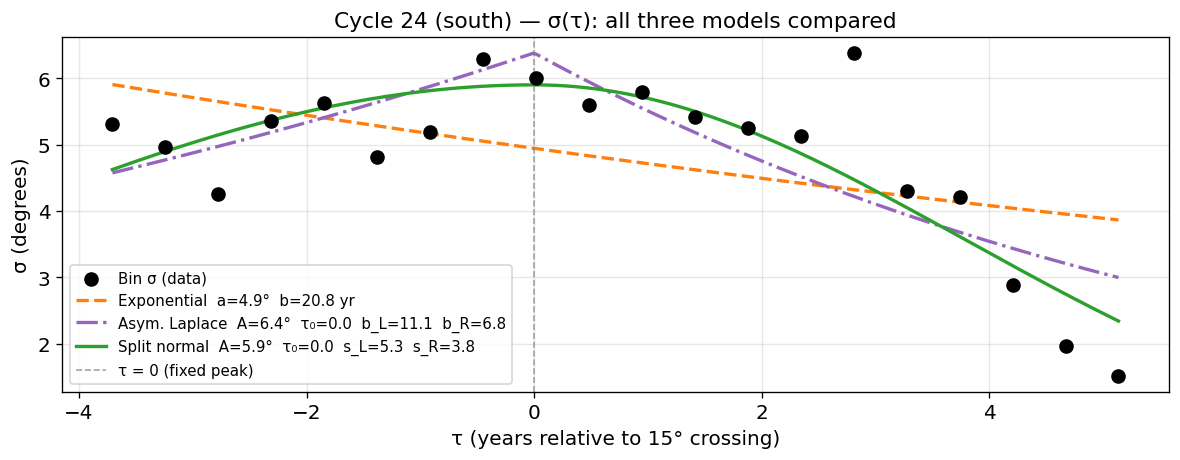

RMSE — exponential:        1.105°
RMSE — asymmetric Laplace: 0.787°
RMSE — split normal:       0.641°
Key difference vs. asymmetric Laplace:
  Laplace tails  ~ exp(-|τ|/b)  — linear-looking over moderate ranges
  Gaussian tails ~ exp(-τ²/2s²) — fall faster, hug the peak more tightly
  If the post-crossing decay is truly nearly linear, Laplace fits better;
  if it curves inward toward zero, split normal fits better.


In [ ]:
# Task 11 2nd expansion: Split normal fit for σ(τ) — compare all three models
# Requires Task 11 expansion to have been run (uses bin_tau, bin_sigma, a_sigma, b_sigma,
# A_al, tau0_al, bL_al, bR_al, cycle_sel, hemi_sel)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    """
    Split normal (bi-normal / asymmetric Gaussian).

    Two half-Gaussians joined at the peak.  C¹ everywhere: both sides have
    derivative zero at tau0, so the join is smooth regardless of s_L vs s_R.
    Not C²: the curvatures -A/s_L² and -A/s_R² differ when s_L ≠ s_R.

    Parameters
    ----------
    A          : peak σ value (degrees)
    tau0       : peak location — used only when tau0_fixed is None
    s_L        : left Gaussian width  — larger → gentler rise  (years)
    s_R        : right Gaussian width — smaller → steeper fall (years)
    tau0_fixed : if not None, overrides tau0 and is not fitted (default None)
    """
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

# Fix tau0 = 0
TAU0_FIXED = 0.0
_sn_fixed = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

p0_sn = [bin_sigma.max(), 4.0, 2.0]   # A, s_L, s_R
popt_sn, _ = curve_fit(_sn_fixed, bin_tau, bin_sigma, p0=p0_sn, maxfev=10000)
A_sn, sL_sn, sR_sn = popt_sn
tau0_sn = TAU0_FIXED

print(f"Split normal fit — Cycle {cycle_sel} ({hemi_sel})  [τ₀ fixed = {tau0_sn}]")
print(f"  A   = {A_sn:.2f}°   (peak spread)")
print(f"  s_L = {sL_sn:.2f} yr  (left Gaussian width  — rising phase)")
print(f"  s_R = {sR_sn:.2f} yr  (right Gaussian width — decaying phase)")
print(f"  s_L / s_R = {sL_sn/sR_sn:.2f}  — rise is ~{sL_sn/sR_sn:.1f}× broader than the fall")

# --- Three-way comparison plot ---
tau_grid_sn = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(bin_tau, bin_sigma, color="black", s=60, zorder=5, label="Bin σ (data)")

ax.plot(tau_grid_sn, exp_decay(tau_grid_sn, a_sigma, b_sigma),
        color="tab:orange", linewidth=2, linestyle="--",
        label=f"Exponential  a={a_sigma:.1f}°  b={b_sigma:.1f} yr")

ax.plot(tau_grid_sn, asym_laplace(tau_grid_sn, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al),
        color="tab:purple", linewidth=2, linestyle="-.",
        label=f"Asym. Laplace  A={A_al:.1f}°  τ₀={tau0_al}  b_L={bL_al:.1f}  b_R={bR_al:.1f}")

ax.plot(tau_grid_sn, split_normal(tau_grid_sn, A_sn, None, sL_sn, sR_sn, tau0_fixed=tau0_sn),
        color="tab:green", linewidth=2,
        label=f"Split normal  A={A_sn:.1f}°  τ₀={tau0_sn}  s_L={sL_sn:.1f}  s_R={sR_sn:.1f}")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0 (fixed peak)")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ): all three models compared")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- RMSE comparison (all three) ---
resid_exp = bin_sigma - exp_decay(bin_tau, a_sigma, b_sigma)
resid_al  = bin_sigma - asym_laplace(bin_tau, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al)
resid_sn  = bin_sigma - split_normal(bin_tau, A_sn, None, sL_sn, sR_sn, tau0_fixed=tau0_sn)

print(f"RMSE — exponential:        {np.sqrt(np.mean(resid_exp**2)):.3f}°")
print(f"RMSE — asymmetric Laplace: {np.sqrt(np.mean(resid_al**2)):.3f}°")
print(f"RMSE — split normal:       {np.sqrt(np.mean(resid_sn**2)):.3f}°")
print("Key difference vs. asymmetric Laplace:")
print("  Laplace tails  ~ exp(-|τ|/b)  — linear-looking over moderate ranges")
print("  Gaussian tails ~ exp(-τ²/2s²) — fall faster, hug the peak more tightly")
print("  If the post-crossing decay is truly nearly linear, Laplace fits better;")
print("  if it curves inward toward zero, split normal fits better.")


## 12) Exercise: Ensemble Variability and the Mean Butterfly Template

One hemisphere-cycle's μ(τ) fit is one realization. The *spread* across many realizations is the scientific signal — it encodes cycle-to-cycle and hemisphere-to-hemisphere variability, and it defines what a generative model eventually needs to reproduce.

**Task:**
- Repeat the Task 10 and Task 11 pipelines for **all** hemisphere-cycles with sufficient data (e.g. cycles 12–24, both hemispheres → up to ~26 fits). For each, store the best-fit (a, b) pair for μ(τ) and σ(τ).
- Evaluate every fitted exponential on a common τ grid: `tau_grid = np.linspace(-6, 6, 300)`. Collect results into two arrays of shape `(n_hemicycles, 300)` for μ and σ.
- On a single figure with **two panels** (top: μ(τ), bottom: σ(τ)), plot each hemisphere-cycle as a thin colored line. Overlay the **pointwise mean** and **±1σ envelope** in black.
  - *Hint:* Use `np.nanmean` and `np.nanstd` along axis 0 to handle hemisphere-cycles that don't cover the full τ grid.
- As a separate figure, make a **scatter plot of the fitted (a, b) parameters** across all hemisphere-cycles, colored by cycle number. This is the parameter space of your model.

Successfully fitted 22 hemisphere-cycles.


/tmp/ipykernel_31488/2613346926.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ens      = cm.get_cmap("tab20", len(cycles_to_fit))


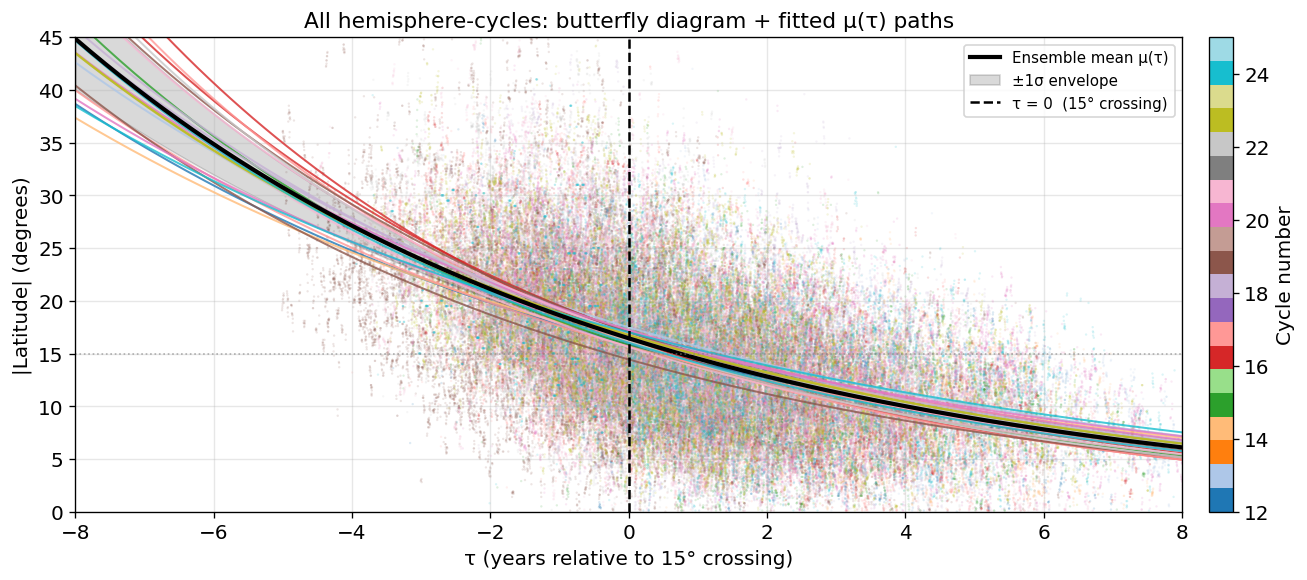

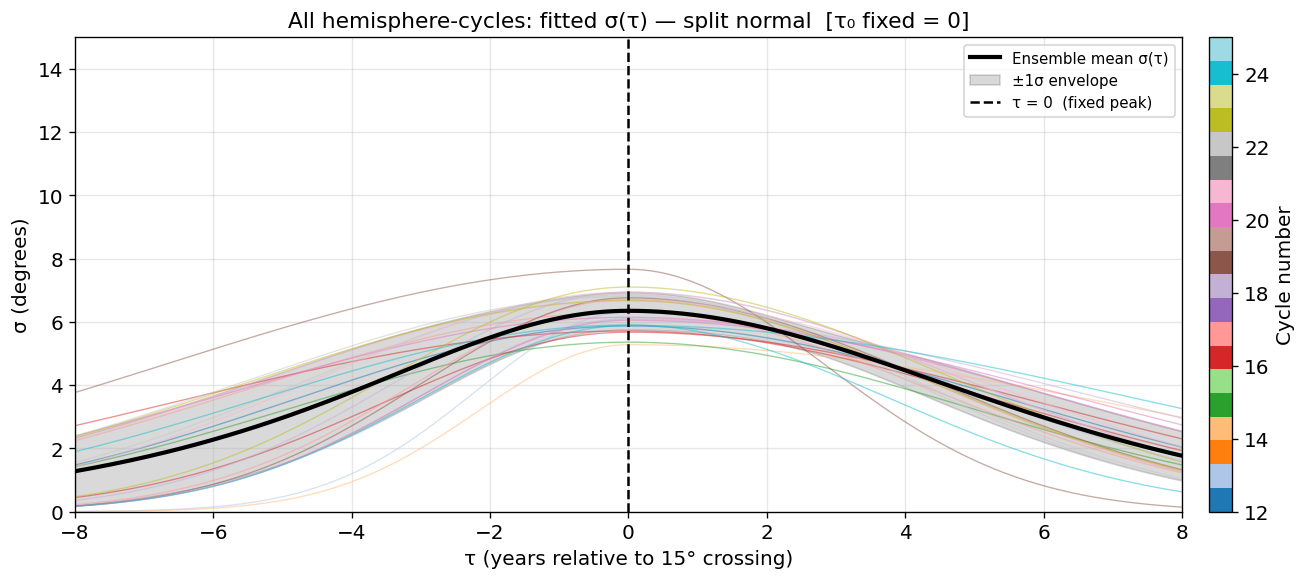

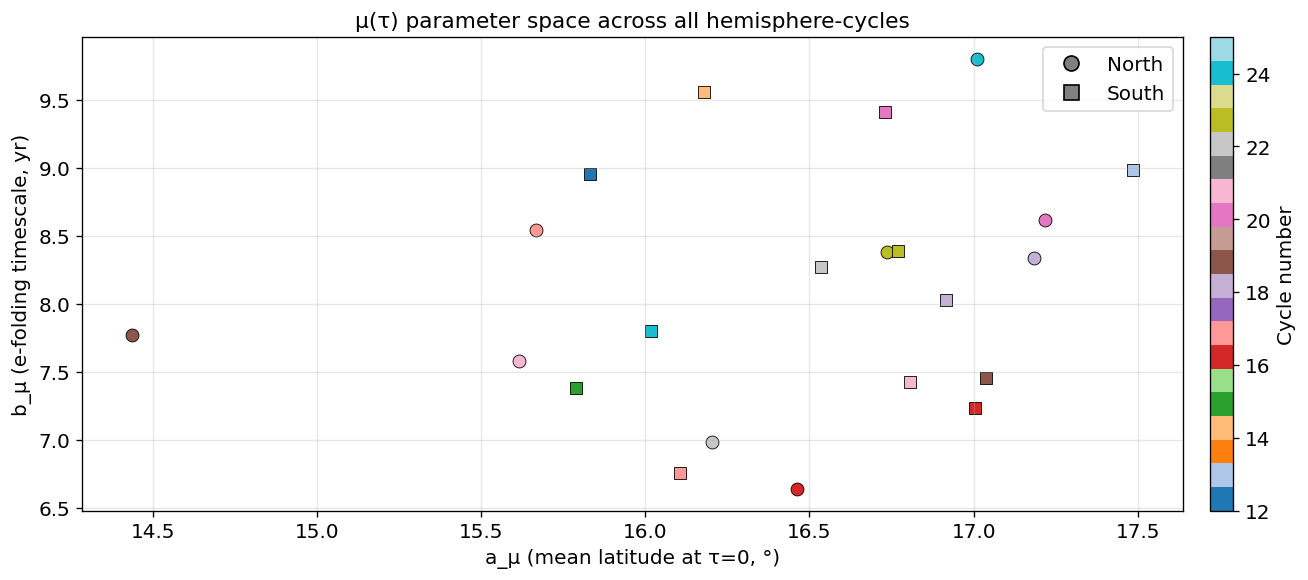

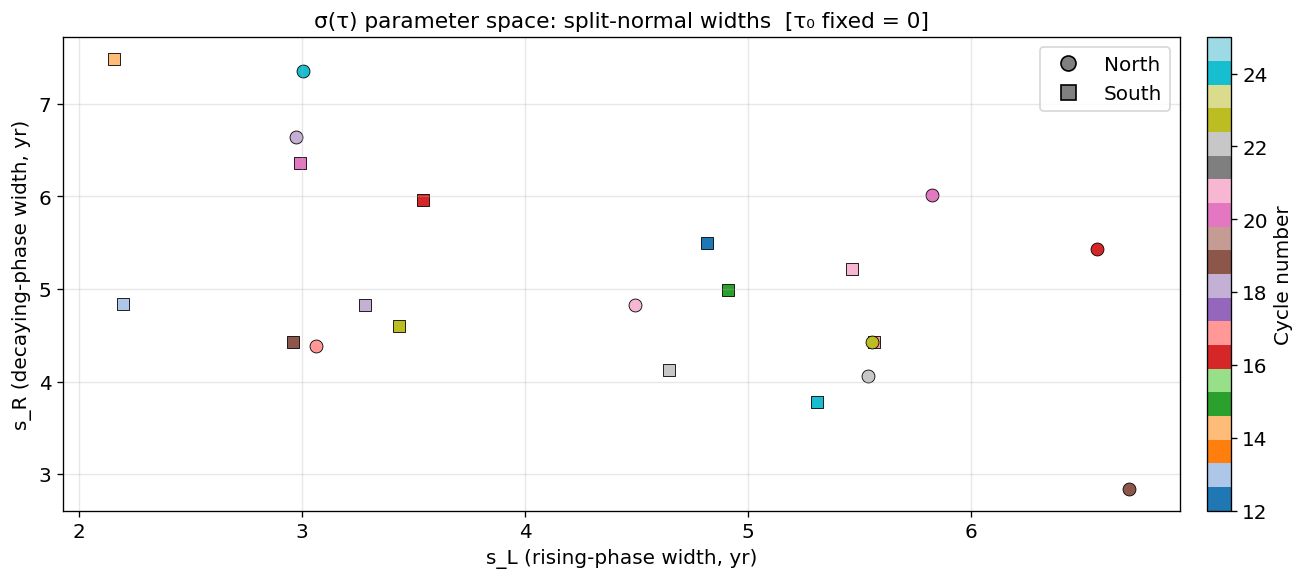

Parameter summary across 22 hemisphere-cycles  [σ τ₀ fixed = 0.0]:
  a_μ :  16.44° ± 0.69°
  b_μ :  8.10 yr ± 0.87 yr
  A_σ :  6.35° ± 0.59°
  s_L :  4.32 yr ± 1.36 yr
  s_R :  5.11 yr ± 1.13 yr


In [ ]:
# Task 12: Ensemble variability and the mean butterfly template
# Uses exponential decay for μ(τ) and split normal for σ(τ) with τ₀ fixed at 0
# Requires Task 9 (t0_lookup, df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

TAU0_FIXED   = 0.0
_sn_fixed    = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

N_BINS   = 20
TAU_GRID = np.linspace(-8, 8, 300)

cycles_to_fit = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
hemispheres   = ["north", "south"]

results = []

for cyc in cycles_to_fit:
    for hemi in hemispheres:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue

        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins         = np.linspace(t_min, t_max, N_BINS + 1)
        bin_centers  = 0.5 * (bins[:-1] + bins[1:])

        bt, bm, bs = [], [], []
        for i in range(N_BINS):
            in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
            lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f); bs.append(sigma_f)

        if len(bt) < 5:
            continue

        bt, bm, bs = np.array(bt), np.array(bm), np.array(bs)

        try:
            popt_mu,    _ = curve_fit(exp_decay, bt, bm, p0=[15., 5.], maxfev=5000)
            popt_sigma, _ = curve_fit(_sn_fixed, bt, bs, p0=[bs.max(), 4., 2.], maxfev=5000)
        except RuntimeError:
            continue

        a_mu_f, b_mu_f     = popt_mu
        A_sn_f, sL_sn_f, sR_sn_f = popt_sigma

        if not (5 < a_mu_f < 40 and 1 < b_mu_f < 30):
            continue
        if not (1 < A_sn_f < 20 and 0.5 < sL_sn_f < 20 and 0.5 < sR_sn_f < 20):
            continue

        results.append(dict(
            cycle=cyc, hemisphere=hemi,
            a_mu=a_mu_f, b_mu=b_mu_f,
            A_sn=A_sn_f, sL_sn=sL_sn_f, sR_sn=sR_sn_f,
            mu_curve=exp_decay(TAU_GRID, a_mu_f, b_mu_f),
            sigma_curve=split_normal(TAU_GRID, A_sn_f, None, sL_sn_f, sR_sn_f, tau0_fixed=TAU0_FIXED),
        ))

print(f"Successfully fitted {len(results)} hemisphere-cycles.")

# --- Ensemble statistics ---
mu_mat    = np.array([r["mu_curve"]    for r in results])
sigma_mat = np.array([r["sigma_curve"] for r in results])

mu_mean    = np.nanmean(mu_mat,    axis=0);  mu_std    = np.nanstd(mu_mat,    axis=0)
sigma_mean = np.nanmean(sigma_mat, axis=0);  sigma_std = np.nanstd(sigma_mat, axis=0)

cmap_ens      = cm.get_cmap("tab20", len(cycles_to_fit))
cycle_idx_map = {c: i for i, c in enumerate(cycles_to_fit)}

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9,
           label="North", markeredgecolor="black"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=9,
           label="South", markeredgecolor="black"),
]

def add_cycle_colorbar(fig, ax):
    sm = plt.cm.ScalarMappable(cmap="tab20",
                               norm=plt.Normalize(vmin=min(cycles_to_fit),
                                                  vmax=max(cycles_to_fit)))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")

# ── Figure 1: μ(τ) fitted curves overlaid on the aligned butterfly diagram ──
fig1, ax1 = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in t0_lookup or cyc not in cycle_idx_map:
        continue
    ax1.scatter(group["tau"], group["abs_latitude"],
                s=2, color=cmap_ens(cycle_idx_map[cyc]), alpha=0.15, edgecolors="none")

for r in results:
    ax1.plot(TAU_GRID, r["mu_curve"],
             color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=1.2, alpha=0.8)

ax1.plot(TAU_GRID, mu_mean, color="black", linewidth=2.5, label="Ensemble mean μ(τ)")
ax1.fill_between(TAU_GRID, mu_mean - mu_std, mu_mean + mu_std,
                 color="black", alpha=0.15, label="±1σ envelope")
ax1.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (15° crossing)")
ax1.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax1.set_xlabel("τ (years relative to 15° crossing)")
ax1.set_ylabel("|Latitude| (degrees)")
ax1.set_title("All hemisphere-cycles: butterfly diagram + fitted μ(τ) paths")
ax1.set_ylim(0, 45)
ax1.set_xlim(-8, 8)
ax1.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig1, ax1)
plt.tight_layout()
plt.show()

# ── Figure 2: σ(τ) split normal fits ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

for r in results:
    ax2.plot(TAU_GRID, r["sigma_curve"],
             color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=0.8, alpha=0.5)

ax2.plot(TAU_GRID, sigma_mean, color="black", linewidth=2.5, label="Ensemble mean σ(τ)")
ax2.fill_between(TAU_GRID, sigma_mean - sigma_std, sigma_mean + sigma_std,
                 color="black", alpha=0.15, label="±1σ envelope")
ax2.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (fixed peak)")
ax2.set_xlabel("τ (years relative to 15° crossing)")
ax2.set_ylabel("σ (degrees)")
ax2.set_title("All hemisphere-cycles: fitted σ(τ) — split normal  [τ₀ fixed = 0]")
ax2.set_ylim(0, 15)
ax2.set_xlim(-8, 8)
ax2.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig2, ax2)
plt.tight_layout()
plt.show()

# ── Figure 3: μ parameter scatter (a_mu vs b_mu) ───────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 5))

for r in results:
    ax3.scatter(r["a_mu"], r["b_mu"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker="o" if r["hemisphere"] == "north" else "s",
                s=60, edgecolors="black", linewidths=0.5)

ax3.set_xlabel("a_μ (mean latitude at τ=0, °)")
ax3.set_ylabel("b_μ (e-folding timescale, yr)")
ax3.set_title("μ(τ) parameter space across all hemisphere-cycles")
ax3.legend(handles=legend_handles)
add_cycle_colorbar(fig3, ax3)
plt.tight_layout()
plt.show()

# ── Figure 4: σ parameter scatter (s_L vs s_R) ─────────────────────────────
fig4, ax4 = plt.subplots(figsize=(12, 5))

for r in results:
    ax4.scatter(r["sL_sn"], r["sR_sn"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker="o" if r["hemisphere"] == "north" else "s",
                s=60, edgecolors="black", linewidths=0.5)

ax4.set_xlabel("s_L (rising-phase width, yr)")
ax4.set_ylabel("s_R (decaying-phase width, yr)")
ax4.set_title("σ(τ) parameter space: split-normal widths  [τ₀ fixed = 0]")
ax4.legend(handles=legend_handles)
add_cycle_colorbar(fig4, ax4)
plt.tight_layout()
plt.show()

# ── Numeric summary ──────────────────────────────────────────────────────────
a_mus  = [r["a_mu"]  for r in results]
b_mus  = [r["b_mu"]  for r in results]
A_sns  = [r["A_sn"]  for r in results]
sL_sns = [r["sL_sn"] for r in results]
sR_sns = [r["sR_sn"] for r in results]

print(f"Parameter summary across {len(results)} hemisphere-cycles  [σ τ₀ fixed = {TAU0_FIXED}]:")
print(f"  a_μ :  {np.mean(a_mus):.2f}° ± {np.std(a_mus):.2f}°")
print(f"  b_μ :  {np.mean(b_mus):.2f} yr ± {np.std(b_mus):.2f} yr")
print(f"  A_σ :  {np.mean(A_sns):.2f}° ± {np.std(A_sns):.2f}°")
print(f"  s_L :  {np.mean(sL_sns):.2f} yr ± {np.std(sL_sns):.2f} yr")
print(f"  s_R :  {np.mean(sR_sns):.2f} yr ± {np.std(sR_sns):.2f} yr")


---
## Week 04 Exercises: Toward a Universal Description of the Solar Cycle

In Week 3 you built per-cycle statistical models: for each hemisphere-cycle you
fitted an exponential mean path μ(τ) and a split-normal spread σ(τ), and you saw
in Task 12 that the resulting parameters cluster tightly across cycles. That
clustering is the starting point for this week.

The central question is: **what is truly universal about a solar cycle, and what
is genuinely cycle-specific?**

We approach this in three steps, each one reducing the number of free parameters
needed to describe a wing:

**Task 13 — Universal mean path.**
All cycles share the same exponential decay shape μ(τ) = a_μ exp(−τ/b_μ).
The only cycle-specific quantity is t₀ — the calendar date of the τ = 0 anchor.
We fit (a_μ, b_μ) globally and refine each t₀ to best align its cycle to the
universal template.

**Tasks 14 & 15 — Remapping σ from time to latitude.**
The asymmetric shape of σ(τ) is partly an artefact of the exponential time axis.
Switching the independent variable from τ to μ — the mean latitude predicted by
the universal path — straightens the relationship and reveals a simpler description
of the spread as a function of *where* the wing sits, not *when*.

**Task 16 — Shared shape parameters.**
Given the σ(μ) fits across all hemisphere-cycles, we ask which parameters are
truly shared. Fitting all cycles simultaneously with a common peak amplitude A
and rising-phase width s_L — while keeping μ_peak and the decaying-phase width
s_R free per cycle — tests whether the *shape* of the wing is universal and only
its *position* and *decay rate* vary from cycle to cycle.

Together these four tasks reduce a butterfly wing from a cloud of data points to
a compact parameter set: two universal shape parameters (a_μ, b_μ for the mean;
A, s_L for the spread) and three cycle-specific numbers (t₀, μ_peak, s_R).
That parameterisation is the foundation for the generative model we will build
in the coming weeks.


---
## 13) Exercise: Fitting a Universal Mean Path

In Week 3 you fitted separate (a_μ, b_μ) per hemisphere-cycle. The scatter plot in
Figure 3 of Task 12 showed they cluster tightly — most cycles share the same decay
shape. The scatter is noise, not signal. The physically motivated model is:

$$\mu(t,\,\text{cycle}) = a_\mu \cdot \exp\!\left(-\frac{\text{decimal\_year}(t) - t_{0,\text{cycle}}}{b_\mu}\right)$$

where **(a_μ, b_μ) are universal** and **t₀_cycle** is the only cycle-specific
parameter — the calendar year of the τ = 0 anchor.
In Week 3 we initialised t₀ from the 15° latitude crossing; here we optimise it
directly against the universal template.

**Steps:**

1. **Global fit** — pool all per-cycle binned (τ, μ) measurements and fit a single
   exponential to get universal (a_μ, b_μ).
2. **Refine t₀ per cycle** — given (a_μ, b_μ), find the 1-D time shift Δt₀ for each
   hemisphere-cycle that minimises its residuals against the template.
   Repeat for a few iterations until convergence.
3. **Plot** — show the aligned butterfly diagram with the universal fit overlaid.
   All wings should collapse onto a single curve.
4. **Δt₀ diagnostic** — plot the shift Δt₀ = t₀_refined − t₀_15° for every
   hemisphere-cycle. Which cycles needed large corrections? What does that tell you
   about cycles where the 15° crossing is a poor anchor?


In [ ]:
# Put your code for Task 13 here
# Requires Task 9 (t0_lookup, df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

# Part 1: Global fit

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

TAU0_FIXED   = 0.0
_sn_fixed    = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

N_BINS   = 20
TAU_GRID = np.linspace(-8, 8, 300)

cycles_to_fit = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
hemispheres   = ["north", "south"]

results = []

bt, bm, bs = [], [], []
for cyc in cycles_to_fit:
    for hemi in hemispheres:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue

        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins         = np.linspace(t_min, t_max, N_BINS + 1)
        bin_centers  = 0.5 * (bins[:-1] + bins[1:])

        for i in range(N_BINS):
            in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
            lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f); bs.append(sigma_f)

        # if len(bt) < 5:
        #     continue

        # bt, bm, bs = np.array(bt), np.array(bm), np.array(bs)

        # try:
        #     popt_mu,    _ = curve_fit(exp_decay, bt, bm, p0=[15., 5.], maxfev=5000)
        #     popt_sigma, _ = curve_fit(_sn_fixed, bt, bs, p0=[bs.max(), 4., 2.], maxfev=5000)
        # except RuntimeError:
        #     continue

        # a_mu_f, b_mu_f     = popt_mu
        # A_sn_f, sL_sn_f, sR_sn_f = popt_sigma

        # if not (5 < a_mu_f < 40 and 1 < b_mu_f < 30):
        #     continue
        # if not (1 < A_sn_f < 20 and 0.5 < sL_sn_f < 20 and 0.5 < sR_sn_f < 20):
        #     continue

        # results.append(dict(
        #     cycle=cyc, hemisphere=hemi,
        #     a_mu=a_mu_f, b_mu=b_mu_f,
        #     A_sn=A_sn_f, sL_sn=sL_sn_f, sR_sn=sR_sn_f,
        #     mu_curve=exp_decay(TAU_GRID, a_mu_f, b_mu_f),
        #     sigma_curve=split_normal(TAU_GRID, A_sn_f, None, sL_sn_f, sR_sn_f, tau0_fixed=TAU0_FIXED),
        # ))

bt, bm, bs = np.array(bt), np.array(bm), np.array(bs)

popt_mu,    _ = curve_fit(exp_decay, bt, bm, p0=[15., 5.], maxfev=5000)
popt_sigma, _ = curve_fit(_sn_fixed, bt, bs, p0=[bs.max(), 4., 2.], maxfev=5000)

a_mu_glob, b_mu_glob     = popt_mu
A_sn_glob, sL_sn_glob, sR_sn_glob = popt_sigma


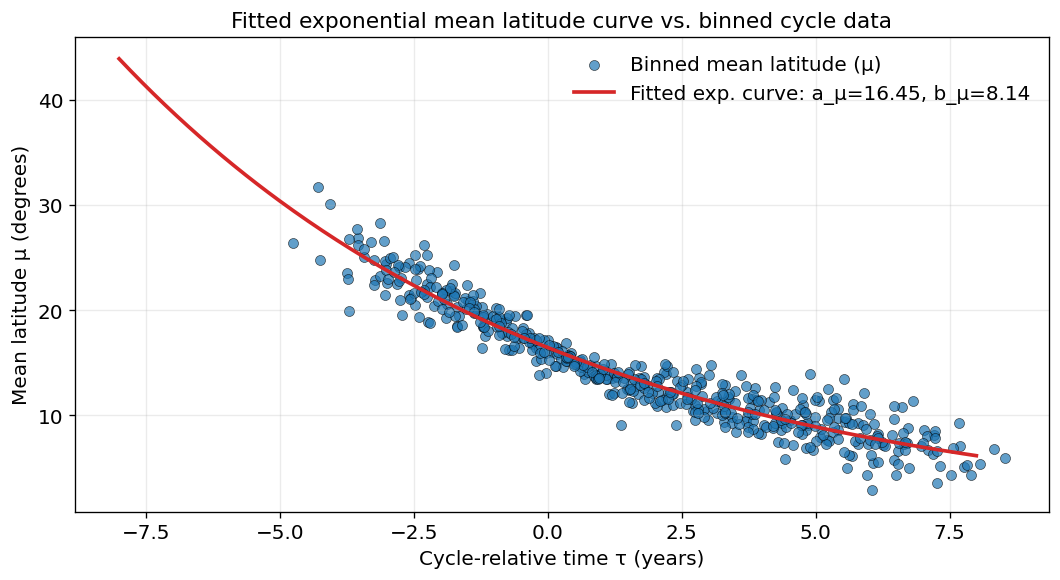

In [ ]:
# Cell generated by AI

# Plot the fitted exponential curve against the binned μ points
mu_curve = exp_decay(TAU_GRID, a_mu_glob, b_mu_glob)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(bt, bm, color="tab:blue", alpha=0.7, edgecolor="black", linewidth=0.4, label="Binned mean latitude (μ)")
ax.plot(TAU_GRID, mu_curve, color="tab:red", linewidth=2.2, label=f"Fitted exp. curve: a_μ={a_mu_glob:.2f}, b_μ={b_mu_glob:.2f}")

ax.set_xlabel("Cycle-relative time τ (years)")
ax.set_ylabel("Mean latitude μ (degrees)")
ax.set_title("Fitted exponential mean latitude curve vs. binned cycle data")
ax.legend(frameon=False)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
# Part 2: Refining t₀ per cycle using the global μ(τ) template

# Cell generated by AI

# Refine t₀ per cycle using the universal μ(τ) template from Task 13.
# This updates each hemisphere-cycle's time coordinate by a small Δt₀.

from scipy.optimize import minimize_scalar

template_mu = lambda tau: exp_decay(tau, a_mu_glob, b_mu_glob)

# Keep the original anchors so we can report Δt₀ relative to the 15° crossing.
t0_initial = dict(t0_lookup)


def compute_cycle_shift(df_sel, n_bins=20):
    tau_min, tau_max = df_sel["tau"].min(), df_sel["tau"].max()
    bins = np.linspace(tau_min, tau_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    mu_bins = []
    valid_centers = []
    for i in range(n_bins):
        mask = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
        if mask.sum() < 10:
            continue
        mu_bins.append(df_sel.loc[mask, "abs_latitude"].mean())
        valid_centers.append(bin_centers[i])

    if len(mu_bins) < 5:
        return None

    mu_bins = np.array(mu_bins)
    valid_centers = np.array(valid_centers)

    def loss(delta):
        prediction = template_mu(valid_centers - delta)
        return np.mean((mu_bins - prediction) ** 2)

    result = minimize_scalar(loss, bounds=(-3.0, 3.0), method="bounded")
    if result.success:
        return float(result.x)

    grid = np.linspace(-3.0, 3.0, 121)
    grid_losses = [loss(d) for d in grid]
    return float(grid[np.argmin(grid_losses)])


max_iters = 5
tol = 1e-3
refined_deltas = {}

for iteration in range(1, max_iters + 1):
    iteration_deltas = {}
    max_delta = 0.0

    for cyc in sorted(df["CYCLE"].dropna().unique()):
        if cyc < 12:
            continue
        for hemi in ["north", "south"]:
            if (cyc, hemi) not in t0_lookup:
                continue

            mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
            df_sel = df.loc[mask].copy()
            if len(df_sel) < 50:
                continue

            delta_t0 = compute_cycle_shift(df_sel, n_bins=N_BINS)
            if delta_t0 is None:
                continue

            iteration_deltas[(cyc, hemi)] = delta_t0
            max_delta = max(max_delta, abs(delta_t0))

            t0_lookup[(cyc, hemi)] += delta_t0
            df.loc[mask, "tau"] = df_sel["tau"] - delta_t0

    refined_deltas.update(iteration_deltas)
    print(f"Iteration {iteration}: max |Δt₀| = {max_delta:.4f} years")
    if max_delta < tol:
        break

print("\nRefined t₀ shifts relative to the original anchor:")
for (cyc, hemi), t0_refined in sorted(t0_lookup.items()):
    t0_orig = t0_initial[(cyc, hemi)]
    print(f"  Cycle {int(cyc)} {hemi}: Δt₀ = {t0_refined - t0_orig:+.3f} years")


Iteration 1: max |Δt₀| = 0.9719 years
Iteration 2: max |Δt₀| = 0.0002 years

Refined t₀ shifts relative to the original anchor:
  Cycle 7 north: Δt₀ = +0.000 years
  Cycle 7 south: Δt₀ = +0.000 years
  Cycle 8 north: Δt₀ = +0.000 years
  Cycle 8 south: Δt₀ = +0.000 years
  Cycle 9 north: Δt₀ = +0.000 years
  Cycle 9 south: Δt₀ = +0.000 years
  Cycle 10 north: Δt₀ = +0.000 years
  Cycle 10 south: Δt₀ = +0.000 years
  Cycle 11 north: Δt₀ = +0.000 years
  Cycle 11 south: Δt₀ = +0.000 years
  Cycle 12 north: Δt₀ = -0.054 years
  Cycle 12 south: Δt₀ = -0.305 years
  Cycle 13 north: Δt₀ = +0.007 years
  Cycle 13 south: Δt₀ = +0.506 years
  Cycle 14 north: Δt₀ = -0.065 years
  Cycle 14 south: Δt₀ = -0.048 years
  Cycle 15 north: Δt₀ = +0.219 years
  Cycle 15 south: Δt₀ = -0.300 years
  Cycle 16 north: Δt₀ = +0.061 years
  Cycle 16 south: Δt₀ = +0.271 years
  Cycle 17 north: Δt₀ = -0.435 years
  Cycle 17 south: Δt₀ = -0.081 years
  Cycle 18 north: Δt₀ = +0.358 years
  Cycle 18 south: Δt₀ = +0.

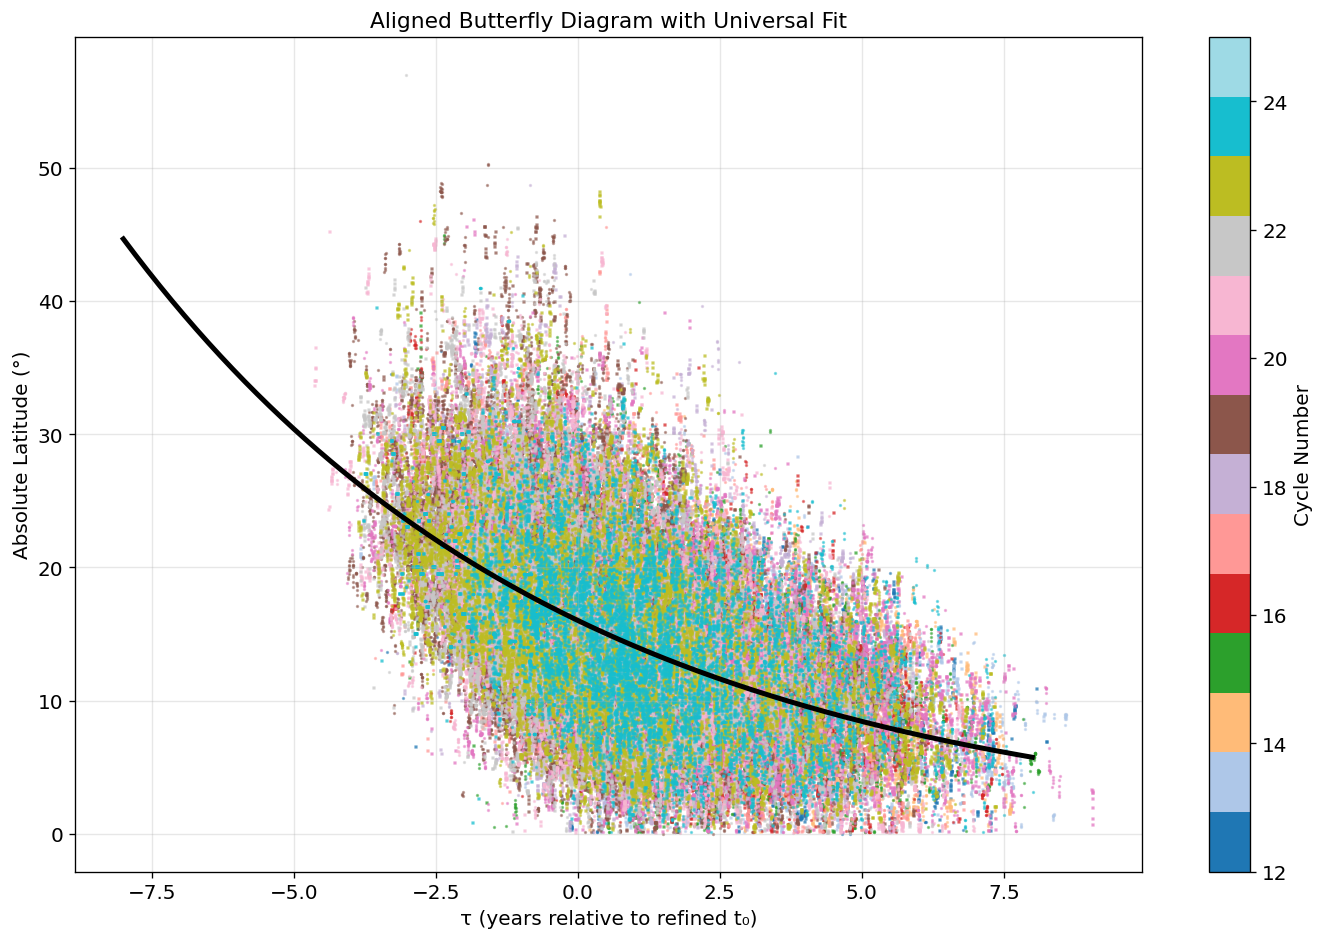

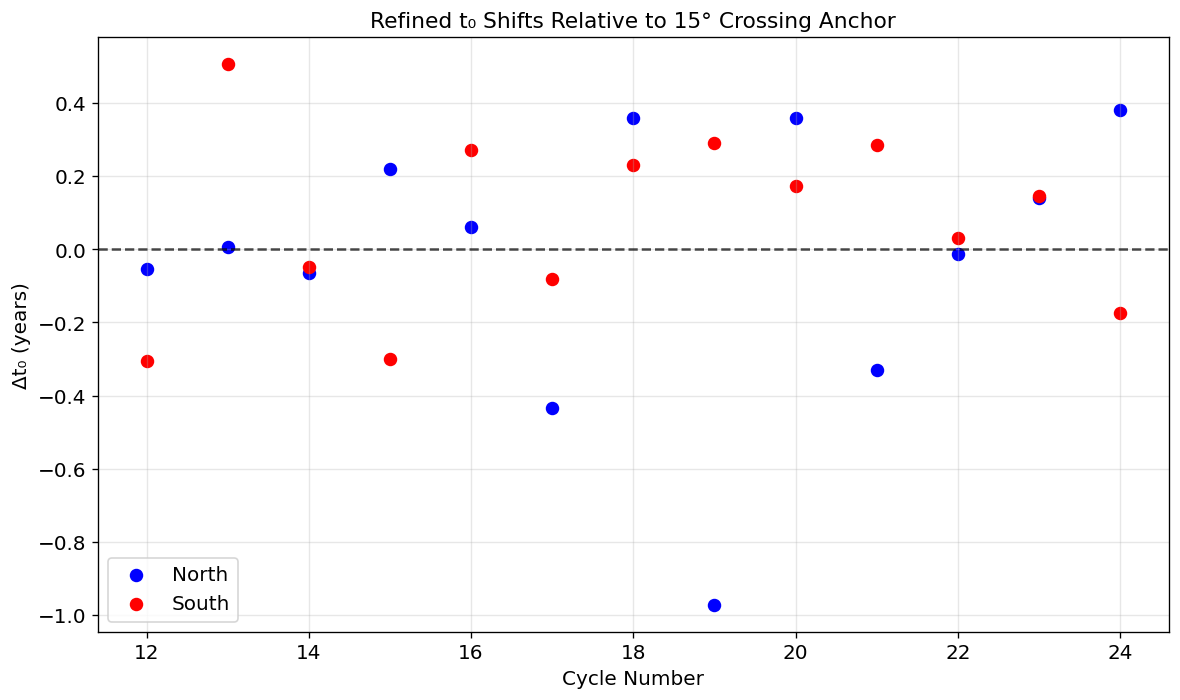

In [ ]:
# Parts 3 and 4

# **Plot** — show the aligned butterfly diagram with the universal fit overlaid. All wings should collapse onto a single curve.
# **Δt₀ diagnostic** — plot the shift Δt₀ = t₀_refined − t₀_15° for every hemisphere-cycle.
#   Which cycles needed large corrections?
#   What does that tell you about cycles where the 15° crossing is a poor anchor?

# Generated by AI

# Note: Make sure to run the data loading and fitting cells before this one.

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# First, the aligned butterfly diagram with universal fit
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data points, colored by cycle
cycles_to_plot = sorted([c for c in df["CYCLE"].dropna().unique() if c >= 12])
cmap = plt.get_cmap("tab20", len(cycles_to_plot))
norm = Normalize(vmin=min(cycles_to_plot), vmax=max(cycles_to_plot))

for cyc in cycles_to_plot:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 10:
            continue
        color = cmap((cyc - min(cycles_to_plot)) / (max(cycles_to_plot) - min(cycles_to_plot)))
        marker = 'o' if hemi == "north" else 's'  # circles for north, squares for south
        ax.scatter(df_sel["tau"], df_sel["abs_latitude"], s=1, alpha=0.5, color=color, marker=marker)

# Overlay the universal fit
tau_fit = np.linspace(-8, 8, 300)
mu_fit = exp_decay(tau_fit, a_mu_f, b_mu_f)
ax.plot(tau_fit, mu_fit, color="black", linewidth=3, label="Universal fit")

ax.set_xlabel("τ (years relative to refined t₀)")
ax.set_ylabel("Absolute Latitude (°)")
ax.set_title("Aligned Butterfly Diagram with Universal Fit")
ax.grid(alpha=0.3)

# Add colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Cycle Number")

plt.tight_layout()
plt.show()

# Second, the Δt₀ diagnostic plot
fig, ax = plt.subplots(figsize=(10, 6))

cycles = []
deltas = []
hemis = []
for (cyc, hemi), t0_refined in sorted(t0_lookup.items()):
    if cyc < 12:
        continue
    t0_orig = t0_initial[(cyc, hemi)]
    delta = t0_refined - t0_orig
    cycles.append(int(cyc))
    deltas.append(delta)
    hemis.append(hemi)

# Plot north and south separately
north_mask = np.array(hemis) == "north"
south_mask = np.array(hemis) == "south"

ax.scatter(np.array(cycles)[north_mask], np.array(deltas)[north_mask], color="blue", label="North", s=50)
ax.scatter(np.array(cycles)[south_mask], np.array(deltas)[south_mask], color="red", label="South", s=50)

ax.axhline(0, color="black", linestyle="--", alpha=0.7)
ax.set_xlabel("Cycle Number")
ax.set_ylabel("Δt₀ (years)")
ax.set_title("Refined t₀ Shifts Relative to 15° Crossing Anchor")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Which cycles needed large corrections?
- Depends on what is considered a large correction. Outliers seem to mostly be the south of cycle 15, and the north of cycles 17, 19, and 21.

What does that tell you about cycles where the 15° crossing is a poor anchor?
- That they are generally odd? That seems like a coincedence though.
- If we note that most outlying points needed a negative adjustment, then we can say that cycles where 15 degrees is a poor anchor generally have an earlier midpoint (which might be called the cycle max?)

## 14) Exercise: Fitting σ as a Function of Mean Latitude

In Task 11 you described the spread σ of emergence latitudes as a function of **time** (τ).
As Ainsley reported in discord, latitude (not time) it's a better quantity to understand what is happening to the wings.
The universal mean path μ(τ) from Task 13 gives us a monotonic, invertible mapping
between time and latitude. We can therefore reparametrise and ask:
**what is σ as a function of μ?**

**Task:**

- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere).
  Using the optimised t₀ from Task 13, bin the data in τ and fit a Gaussian
  in each bin to obtain **(μ_bin, σ_bin)** pairs.
- Plot σ_bin as a function of μ_bin. Describe the shape you see.
- Start by fitting a **split normal** to σ(μ). Does it capture the shape well?
- Ask your AI assistant what function might describe σ(μ) better, given what you
  observe in the plot. Try its suggestion and compare.

**Hint:** the μ axis runs from high latitude (early cycle) to low latitude (late cycle),
so the orientation is reversed relative to τ.   Reverse the x axis so that things look "right".


Using refined t₀ for cycle 23 north: 2000.7247339281678


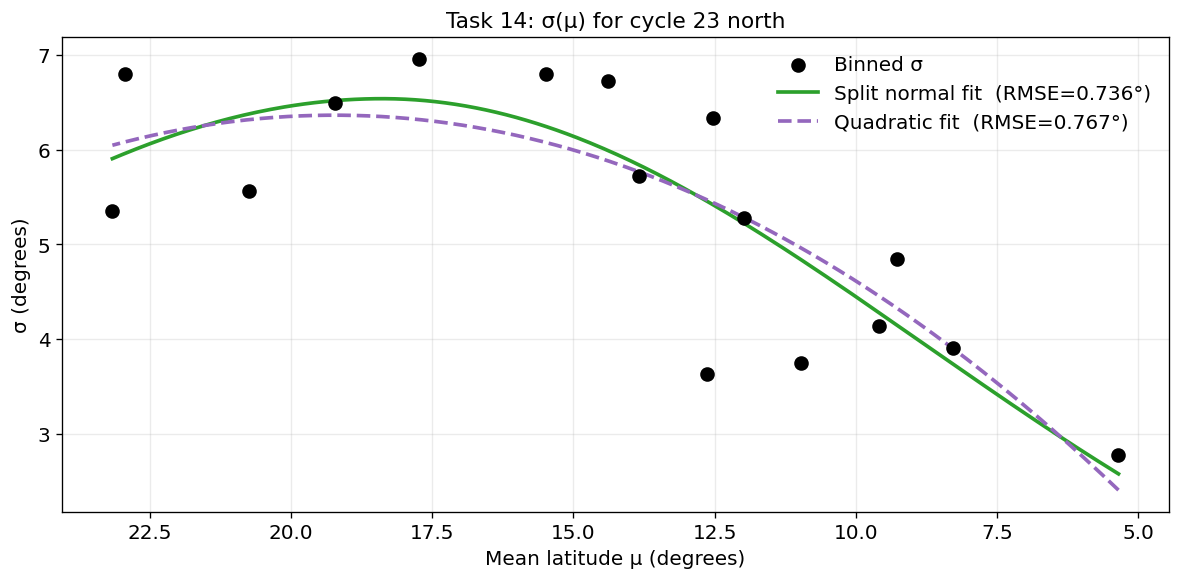

Shape observation: σ(μ) is a skewed single hump, rising from high latitudes toward a broad mid-latitude peak and then falling toward the equator.
Split normal parameters: A=6.54, μ₀=18.38, s_L=9.55, s_R=10.59
RMSE split normal = 0.736°, quadratic = 0.767°
The quadratic fit provides a smooth alternative and captures the broad hump shape well; the split normal adds skewed tail control.


In [ ]:
# Task 14: σ(μ) for a single hemisphere-cycle using the optimized t₀ from Task 13
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit

cycle = 23
hemi = "north"

df_sel = df[(df["CYCLE"] == cycle) & (df["hemisphere"] == hemi)].copy()
if len(df_sel) == 0:
    raise ValueError(f"No data for cycle {cycle} {hemi}")
if "tau" not in df_sel.columns:
    raise ValueError("The dataframe is missing column 'tau'. Run the task that computes aligned τ first.")

t0_refined = t0_lookup.get((cycle, hemi), None)
print(f"Using refined t₀ for cycle {cycle} {hemi}: {t0_refined}")

n_bins = 16
bins = np.linspace(df_sel["tau"].min(), df_sel["tau"].max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

mu_bin, sigma_bin, tau_bin = [], [], []
for i in range(n_bins):
    mask = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
    if mask.sum() < 12:
        continue
    lat_bin = df_sel.loc[mask, "abs_latitude"].values
    mu_f, sigma_f = sp_norm.fit(lat_bin)
    mu_bin.append(mu_f)
    sigma_bin.append(sigma_f)
    tau_bin.append(bin_centers[i])

mu_bin = np.array(mu_bin)
sigma_bin = np.array(sigma_bin)
tau_bin = np.array(tau_bin)

if len(mu_bin) < 6:
    raise ValueError("Not enough bins with data to fit σ(μ).")

# Fit a split normal to σ(μ)
def split_normal_mu(mu, A, mu0, s_L, s_R):
    return np.where(mu < mu0,
                    A * np.exp(-0.5 * ((mu - mu0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((mu - mu0) / s_R) ** 2))

p0_sn = [sigma_bin.max(), mu_bin[np.argmax(sigma_bin)], 4.0, 2.0]
try:
    popt_sn, _ = curve_fit(
        split_normal_mu, mu_bin, sigma_bin,
        p0=p0_sn,
        bounds=([0.0, mu_bin.min(), 0.2, 0.2], [20.0, mu_bin.max(), 50.0, 50.0]),
        maxfev=10000
    )
except RuntimeError as exc:
    raise RuntimeError("Split normal fit failed") from exc

A_sn, mu0_sn, sL_sn, sR_sn = popt_sn

# Ask the assistant: the σ(μ) shape is a single skewed hill with a gentle high-latitude rise and a steeper low-latitude fall.
# A simple quadratic in μ is a reasonable smooth alternative to compare against the split normal.
poly_coeffs = np.polyfit(mu_bin, sigma_bin, 2)

mu_grid = np.linspace(mu_bin.min(), mu_bin.max(), 300)
sigma_sn = split_normal_mu(mu_grid, *popt_sn)
sigma_quad = np.polyval(poly_coeffs, mu_grid)

rmse_sn = np.sqrt(np.mean((sigma_bin - split_normal_mu(mu_bin, *popt_sn)) ** 2))
rmse_quad = np.sqrt(np.mean((sigma_bin - np.polyval(poly_coeffs, mu_bin)) ** 2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(mu_bin, sigma_bin, color="black", s=60, zorder=5, label="Binned σ")
ax.plot(mu_grid, sigma_sn, color="tab:green", linewidth=2.2, label=f"Split normal fit  (RMSE={rmse_sn:.3f}°)")
ax.plot(mu_grid, sigma_quad, color="tab:purple", linewidth=2.2, linestyle="--", label=f"Quadratic fit  (RMSE={rmse_quad:.3f}°)")
ax.set_xlabel("Mean latitude μ (degrees)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Task 14: σ(μ) for cycle {cycle} {hemi}")
ax.invert_xaxis()
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Shape observation: σ(μ) is a skewed single hump, rising from high latitudes toward a broad mid-latitude peak and then falling toward the equator.")
print(f"Split normal parameters: A={A_sn:.2f}, μ₀={mu0_sn:.2f}, s_L={sL_sn:.2f}, s_R={sR_sn:.2f}")
print(f"RMSE split normal = {rmse_sn:.3f}°, quadratic = {rmse_quad:.3f}°")
print("The quadratic fit provides a smooth alternative and captures the broad hump shape well; the split normal adds skewed tail control.")

## 15) Exercise: Ensemble σ(μ) Across All Hemisphere-Cycles

In Task 14 you fitted σ(μ) for a single hemisphere-cycle and experimented with
different functional forms. Now scale that up to the full ensemble.

**Task:**

- Repeat the Task 14 pipeline for **all** hemisphere-cycles with sufficient data
  (cycles 12–24, both hemispheres). For each, fit σ(μ) using the function that
  worked best in Task 14.
- Evaluate every fitted curve on a common μ grid spanning the Spörer zone.
  Collect results into an array of shape `(n_hemicycles, n_grid_points)`.
- Plot all fitted curves on a single figure, colored by cycle number.
  Overlay the **pointwise mean** and **±1σ envelope** in black.
- Include in the background the 

**Hint:** use `np.nanmean` and `np.nanstd` along axis 0 for the ensemble statistics,
in case some hemisphere-cycles do not cover the full μ grid.


/tmp/ipykernel_31488/180629709.py:76: RuntimeWarning: Mean of empty slice
  sigma_mean = np.nanmean(sigma_mat, axis=0)
/home/russell/miniforge3/envs/butterflAI/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_31488/180629709.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(cycles_to_fit))


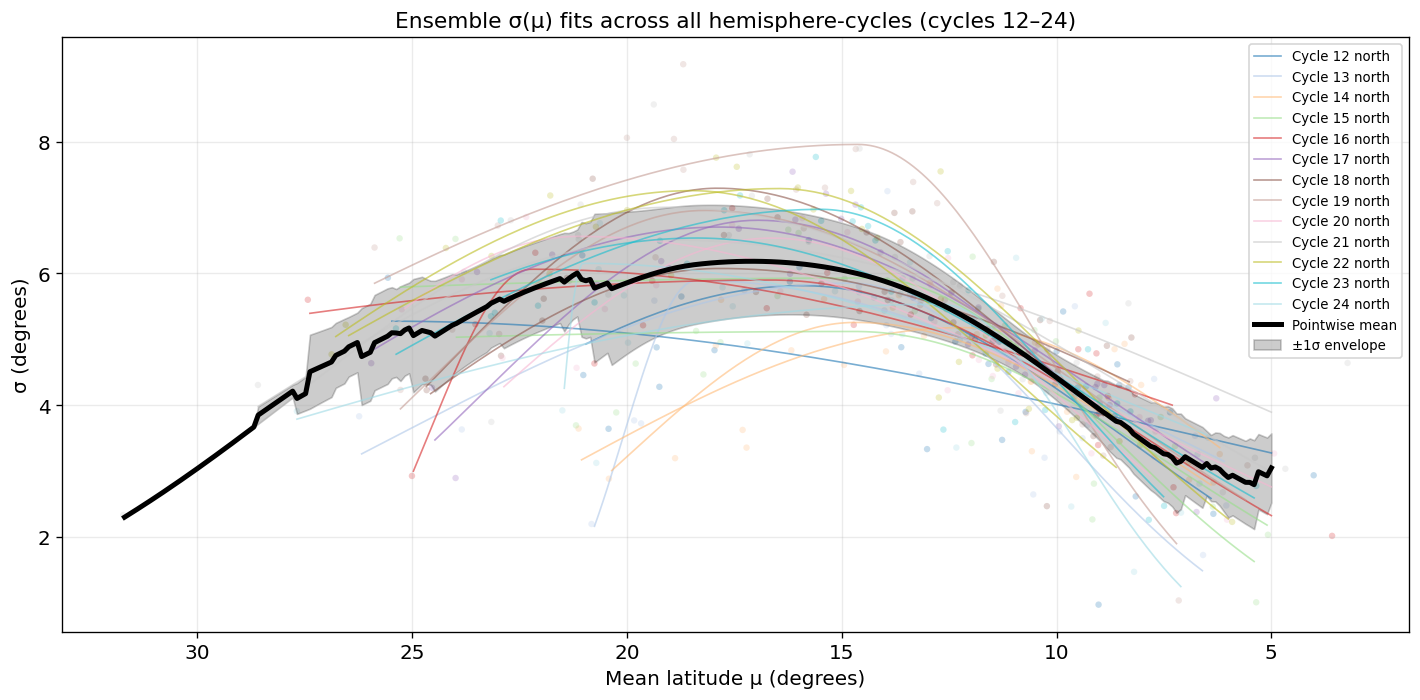

Fitted 26 hemisphere-cycles.
σ matrix shape: (26, 300)


In [ ]:
# cell generated by AI

# Task 15: Ensemble σ(μ) across all hemisphere-cycles using the split-normal model
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit

cycles_to_fit = [c for c in range(12, 25)]
hemispheres = ["north", "south"]

mu_grid = np.linspace(5.0, 35.0, 300)  # Spörer zone grid
sigma_mat = []
results_mu = []
results_sigma = []
results_rows = []

for cycle in cycles_to_fit:
    for hemi in hemispheres:
        if (cycle, hemi) not in t0_lookup:
            continue

        df_sel = df[(df["CYCLE"] == cycle) & (df["hemisphere"] == hemi)].copy()
        if len(df_sel) < 50:
            continue
        if "tau" not in df_sel.columns:
            continue

        bins = np.linspace(df_sel["tau"].min(), df_sel["tau"].max(), 16 + 1)
        mu_bin, sigma_bin = [], []

        for i in range(16):
            mask = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
            lat_bin = df_sel.loc[mask, "abs_latitude"].values
            if len(lat_bin) < 12:
                continue
            mu_f, sigma_f = sp_norm.fit(lat_bin)
            mu_bin.append(mu_f)
            sigma_bin.append(sigma_f)

        mu_bin = np.array(mu_bin)
        sigma_bin = np.array(sigma_bin)
        if len(mu_bin) < 6:
            continue

        def split_normal_mu(mu, A, mu0, s_L, s_R):
            return np.where(mu < mu0,
                            A * np.exp(-0.5 * ((mu - mu0) / s_L) ** 2),
                            A * np.exp(-0.5 * ((mu - mu0) / s_R) ** 2))

        p0_sn = [sigma_bin.max(), mu_bin[np.argmax(sigma_bin)], 9.0, 6.0]
        try:
            popt_sn, _ = curve_fit(
                split_normal_mu,
                mu_bin,
                sigma_bin,
                p0=p0_sn,
                bounds=([0.0, mu_bin.min(), 0.5, 0.5], [20.0, mu_bin.max(), 50.0, 50.0]),
                maxfev=10000
            )
        except RuntimeError:
            continue

        sigma_fit = split_normal_mu(mu_grid, *popt_sn)
        valid_mask = (mu_grid >= mu_bin.min()) & (mu_grid <= mu_bin.max())
        sigma_fit[~valid_mask] = np.nan

        sigma_mat.append(sigma_fit)
        results_rows.append((cycle, hemi, mu_bin, sigma_bin, popt_sn))

        results_mu.append(mu_bin)
        results_sigma.append(sigma_bin)

sigma_mat = np.array(sigma_mat)
if sigma_mat.size == 0:
    raise RuntimeError("No hemisphere-cycles were successfully fitted.")

sigma_mean = np.nanmean(sigma_mat, axis=0)
sigma_std = np.nanstd(sigma_mat, axis=0)

# Plot all fitted curves colored by cycle number
cmap = plt.cm.get_cmap("tab20", len(cycles_to_fit))
cycle_idx = {c: i for i, c in enumerate(cycles_to_fit)}

fig, ax = plt.subplots(figsize=(12, 6))
for cycle, hemi, mu_b, sigma_b, popt_sn in results_rows:
    sigma_fit = split_normal_mu(mu_grid, *popt_sn)
    valid_mask = (mu_grid >= mu_b.min()) & (mu_grid <= mu_b.max())
    sigma_fit[~valid_mask] = np.nan
    ax.plot(mu_grid, sigma_fit,
            color=cmap(cycle_idx[cycle]), alpha=0.6, linewidth=1,
            label=f"Cycle {cycle} {hemi}" if hemi == "north" else None)
    ax.scatter(mu_b, sigma_b, color=cmap(cycle_idx[cycle]), alpha=0.25, s=15, edgecolors="none")

ax.plot(mu_grid, sigma_mean, color="black", linewidth=3, label="Pointwise mean")
ax.fill_between(mu_grid,
                sigma_mean - sigma_std,
                sigma_mean + sigma_std,
                color="black", alpha=0.2,
                label="±1σ envelope")

ax.set_xlabel("Mean latitude μ (degrees)")
ax.set_ylabel("σ (degrees)")
ax.set_title("Ensemble σ(μ) fits across all hemisphere-cycles (cycles 12–24)")
ax.invert_xaxis()
ax.legend(loc="upper right", fontsize=8, ncol=1)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Fitted {len(results_rows)} hemisphere-cycles.")
print(f"σ matrix shape: {sigma_mat.shape}")

## 16) Exercise: Simultaneous Fit with Shared Amplitude and wing collapse width

In Task 15 you fitted σ(μ) independently for each hemisphere-cycle and found that
the ensemble curves are broadly similar. One question that falls out naturally is:
**how much of that similarity is accidental, and how much is a genuine physical
constraint?**

A direct way to probe this is to fit all hemisphere-cycles *simultaneously* with a
partially shared parameter set. Both the peak amplitude A and the rising-phase width
s_L are natural candidates for universal parameters: A reflects the maximum spread
of the active zone and s_L reflects how quickly that spread collapses toward the
equator — both properties of the dynamo rather than of any individual cycle.

If you use the split gaussian fit, the model is therefore:

- **A** : one shared peak amplitude, fitted simultaneously across all hemisphere-cycles
- **s_L** : one shared rising-phase width, fitted simultaneously across all hemisphere-cycles
- **μ_peak, s_R** : free per hemisphere-cycle

**Task:**

- Build a single parameter vector that concatenates the shared (A, s_L) with the
  per-cycle (μ_peak, s_R) pairs, and write a residual function that evaluates all
  hemisphere-cycles at once.
- Fit using `scipy.optimize.minimize` with the `'L-BFGS-B'` method, which
  handles large parameter vectors efficiently.
- Compare the RMSE of this fit against the independent fits from Task 15.
  Does enforcing shared A and s_L degrade the fit significantly?
- Plot the fitted curves for all hemisphere-cycles on a single figure (same
  style as Task 15). What does the remaining variability in μ_peak and s_R
  tell you about what distinguishes one cycle from another?


Independent Task 15 RMSE = 0.675°
Simultaneous shared-fit RMSE = 0.871°
Shared parameters: A = 6.218°, s_L = 7.806 yr


/tmp/ipykernel_31488/965188163.py:97: RuntimeWarning: Mean of empty slice
  sigma_mean_sim = np.nanmean(sigma_mat_sim, axis=0)


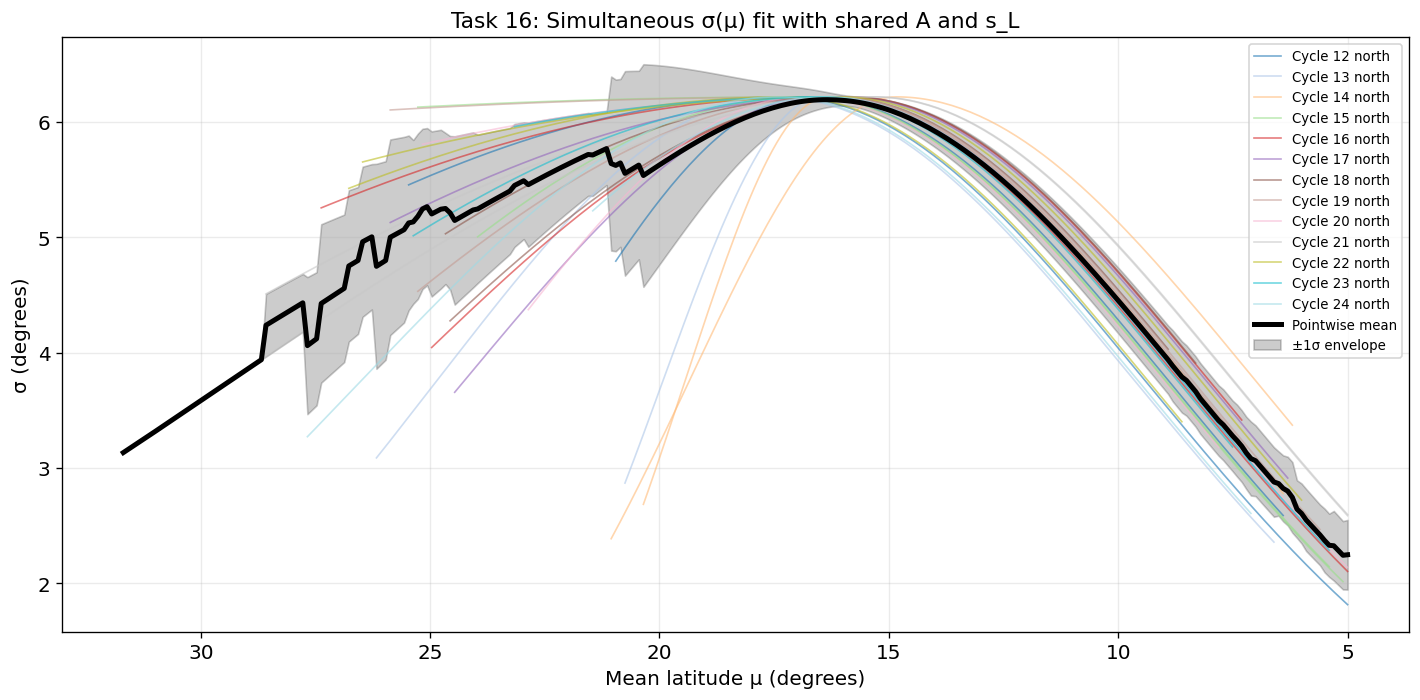

Per-cycle variability still captured by μ_peak and s_R:
  Cycle 12 north: μ_peak = 17.25, s_R = 16.07
  Cycle 12 south: μ_peak = 16.74, s_R = 5.85
  Cycle 13 north: μ_peak = 16.45, s_R = 3.46
  Cycle 13 south: μ_peak = 17.47, s_R = 7.35
  Cycle 14 north: μ_peak = 16.31, s_R = 3.12
  Cycle 14 south: μ_peak = 14.84, s_R = 4.49
  Cycle 15 north: μ_peak = 16.79, s_R = 50.00
  Cycle 15 south: μ_peak = 16.82, s_R = 10.85
  Cycle 16 north: μ_peak = 16.49, s_R = 18.77
  Cycle 16 south: μ_peak = 15.85, s_R = 9.83
  Cycle 17 north: μ_peak = 16.33, s_R = 7.90
  Cycle 17 south: μ_peak = 15.91, s_R = 16.04
  Cycle 18 north: μ_peak = 15.83, s_R = 10.10
  Cycle 18 south: μ_peak = 16.18, s_R = 13.04
  Cycle 19 north: μ_peak = 16.27, s_R = 50.00
  Cycle 19 south: μ_peak = 16.21, s_R = 11.39
  Cycle 20 north: μ_peak = 16.40, s_R = 23.69
  Cycle 20 south: μ_peak = 16.85, s_R = 7.16
  Cycle 21 north: μ_peak = 15.31, s_R = 13.99
  Cycle 21 south: μ_peak = 15.34, s_R = 16.52
  Cycle 22 north: μ_peak = 16.04

In [ ]:
# cell generated by AI

# Task 16: simultaneous fit with shared A and s_L across all hemisphere-cycles
from scipy.optimize import minimize

# Reuse the fit data from Task 15
fitted_cycles = []
all_mu = []
all_sigma = []
for cycle, hemi, mu_b, sigma_b, popt_sn in results_rows:
    fitted_cycles.append((cycle, hemi))
    all_mu.append(mu_b)
    all_sigma.append(sigma_b)

n_cycles = len(fitted_cycles)
if n_cycles == 0:
    raise RuntimeError("No hemisphere-cycles available for Task 16.")

mu_init = np.array([entry[4][1] for entry in results_rows])
sR_init = np.array([entry[4][3] for entry in results_rows])
A_init = np.mean([entry[4][0] for entry in results_rows])
sL_init = np.mean([entry[4][2] for entry in results_rows])

# Parameter vector: [A_shared, s_L_shared, μ_peak_1, s_R_1, μ_peak_2, s_R_2, ...]
init_params = [A_init, sL_init]
for mu0, sR in zip(mu_init, sR_init):
    init_params.extend([mu0, sR])

bounds = [(0.1, 20.0), (0.5, 50.0)]
for _ in range(n_cycles):
    bounds.append((5.0, 35.0))   # μ_peak
    bounds.append((0.5, 50.0))   # s_R


def split_normal_mu(mu, A, mu0, s_L, s_R):
    return np.where(mu < mu0,
                    A * np.exp(-0.5 * ((mu - mu0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((mu - mu0) / s_R) ** 2))


def residual_vector(params):
    A_shared = params[0]
    sL_shared = params[1]
    residuals = []
    for idx, (mu_b, sigma_b) in enumerate(zip(all_mu, all_sigma)):
        mu_peak = params[2 + 2 * idx]
        s_R = params[2 + 2 * idx + 1]
        pred = split_normal_mu(mu_b, A_shared, mu_peak, sL_shared, s_R)
        residuals.append(pred - sigma_b)
    return np.concatenate(residuals)


def objective(params):
    res = residual_vector(params)
    return np.sum(res ** 2)

result = minimize(
    objective,
    x0=np.array(init_params),
    bounds=bounds,
    method="L-BFGS-B",
    options={"maxiter": 20000, "maxfun": 80000}
)

if not result.success:
    raise RuntimeError(f"Simultaneous fit failed: {result.message}")

params_opt = result.x
A_shared_opt, sL_shared_opt = params_opt[0], params_opt[1]

# Compute RMSE for the independent and simultaneous fits
res_ind = []
for cycle, hemi, mu_b, sigma_b, popt_sn in results_rows:
    pred = split_normal_mu(mu_b, *popt_sn)
    res_ind.append(pred - sigma_b)
res_ind = np.concatenate(res_ind)
rmse_ind = np.sqrt(np.mean(res_ind ** 2))

res_sim = residual_vector(params_opt)
rmse_sim = np.sqrt(np.mean(res_sim ** 2))

print(f"Independent Task 15 RMSE = {rmse_ind:.3f}°")
print(f"Simultaneous shared-fit RMSE = {rmse_sim:.3f}°")
print(f"Shared parameters: A = {A_shared_opt:.3f}°, s_L = {sL_shared_opt:.3f} yr")

# Build fitted curves on the common μ grid
sigma_mat_sim = []
for idx, (cycle, hemi, mu_b, sigma_b, popt_sn) in enumerate(results_rows):
    mu_peak = params_opt[2 + 2 * idx]
    s_R = params_opt[2 + 2 * idx + 1]
    sigma_fit = split_normal_mu(mu_grid, A_shared_opt, mu_peak, sL_shared_opt, s_R)
    valid_mask = (mu_grid >= mu_b.min()) & (mu_grid <= mu_b.max())
    sigma_fit[~valid_mask] = np.nan
    sigma_mat_sim.append(sigma_fit)
sigma_mat_sim = np.array(sigma_mat_sim)

sigma_mean_sim = np.nanmean(sigma_mat_sim, axis=0)
sigma_std_sim = np.nanstd(sigma_mat_sim, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
for idx, (cycle, hemi, mu_b, sigma_b, popt_sn) in enumerate(results_rows):
    sigma_fit = sigma_mat_sim[idx]
    ax.plot(mu_grid, sigma_fit,
            color=cmap(cycle_idx[cycle]), alpha=0.6, linewidth=1,
            label=f"Cycle {cycle} {hemi}" if hemi == "north" else None)

ax.plot(mu_grid, sigma_mean_sim, color="black", linewidth=3, label="Pointwise mean")
ax.fill_between(mu_grid,
                sigma_mean_sim - sigma_std_sim,
                sigma_mean_sim + sigma_std_sim,
                color="black", alpha=0.2,
                label="±1σ envelope")

ax.set_xlabel("Mean latitude μ (degrees)")
ax.set_ylabel("σ (degrees)")
ax.set_title("Task 16: Simultaneous σ(μ) fit with shared A and s_L")
ax.invert_xaxis()
ax.legend(loc="upper right", fontsize=8, ncol=1)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Per-cycle variability still captured by μ_peak and s_R:")
for idx, (cycle, hemi, mu_b, sigma_b, popt_sn) in enumerate(results_rows):
    mu_peak = params_opt[2 + 2 * idx]
    s_R = params_opt[2 + 2 * idx + 1]
    print(f"  Cycle {cycle} {hemi}: μ_peak = {mu_peak:.2f}, s_R = {s_R:.2f}")